# Imports and Style

In [3]:
from darklim.utils import get_cache_path

In [4]:
get_cache_path("hello")

'/home/kmoraa/tesseract/DarkLim/darklim/hello'

In [5]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as font_manager
font_manager.fontManager.addfont(get_cache_path('data/styles/Times_New_Roman.ttf'))

import matplotlib as mpl
import matplotlib
matplotlib.rcParams['font.family'] = 'serif'
matplotlib.rcParams['font.serif'] = 'Times New Roman'
plt.rcParams['mathtext.fontset'] = 'stix'

plt.style.use(get_cache_path('data/styles/Style.mplstyle'))

from multihist import Hist1d

from scipy import interpolate

from scipy.interpolate import interp1d

import darklim

import sys
sys.path.insert(0, get_cache_path('data/ExistingLimits/'))
import MichaelLimits as ML

import pandas as pd


%matplotlib inline

def find_nearest(array, value):
    array = np.asarray(array)
    idx = (np.abs(array - value)).argmin()
    return idx, array[idx]

# Functions to plot existing data

In [9]:
def extrapolate(data, mass=1e6):
    m0, s0 = data[-1]
    return np.concatenate([data,[[mass, s0*mass/m0]]], axis=0)

def minbound(curves, masses=None):
    if masses is None:
        masses = np.logspace(-3, 4, 200)
    result = np.array([np.nan]*len(masses))
    for curve in curves:
        if curve[-1][0] < masses[-1]:
            curve = extrapolate(curve, masses[-1])
        yinterp = 10**(interp1d(*(np.log10(curve).T), bounds_error=False)(np.log10(masses)))
        #yinterp = interp1d(*(curve.T), bounds_error=False)(masses)
        result = np.nanmin([result, yinterp], axis=0)
    return np.array([masses, result]).T

def log_interp(zz, xx, yy, left=None, right=None):
    logz = np.log(zz)
    logx = np.log(xx)
    logy = np.log(yy)
    return np.exp(np.interp(logz, logx, logy, left=left, right=right))

def load_and_plot_existing(leg=True, lw=1, leg_params={}, ER_model='massless', cosmic=False, migdal=False, direct=False):
    
    curves_dir = get_cache_path('data/ExistingLimits/')+"/"
    handles = []
    fig, ax = plt.subplots(1, 1, figsize=(10,7.5))
    ax.set_xscale('log')
    ax.set_yscale('log')
    mpl.rcParams['font.size'] = 14
    
    if ER_model == 'massive':

        m_lim, x_lim = np.loadtxt(curves_dir + 'DAMIC_LBC_ER_Massive_2025.txt').transpose()
        l, = ax.plot(m_lim*1e3, x_lim, '--', color='magenta', lw=lw, label='LBC (DAMIC) 2025', alpha=0.5)
        handles.append(l)
        ax.fill_between(m_lim*1e3, x_lim, 1e-18, facecolor='whitesmoke')
        
        m_lim_1, x_lim_1 = np.loadtxt(curves_dir + 'DAMIC_ER_Massive_2023.txt').transpose()
        m_lim_2, x_lim_2 = np.loadtxt(curves_dir + 'DAMIC_ER_Massive_2024.txt').transpose()
        m_lim = np.geomspace(min(m_lim_1[0], m_lim_2[0]), max(m_lim_1[-1], m_lim_2[-1]), 150)
        x_lim_1_adj = log_interp(m_lim, m_lim_1, x_lim_1, left=np.inf, right=np.inf)
        x_lim_2_adj = log_interp(m_lim, m_lim_2, x_lim_2, left=np.inf, right=np.inf)
        x_lim = np.minimum(x_lim_1_adj, x_lim_2_adj)
        l, = ax.plot(m_lim, x_lim, '--', color='#CFC0E5', lw=lw, label='DAMIC 2023, 2024')
        handles.append(l)
        ax.fill_between(m_lim, x_lim, 1e-18, facecolor='whitesmoke')
        
        m_lim, x_lim = np.loadtxt(curves_dir + 'Darkside50_ER_Massive_2023.txt').transpose()
        l, = ax.plot(m_lim, x_lim, '--', color='#CE977A', lw=lw, label='Darkside-50 2023')
        handles.append(l)
        ax.fill_between(m_lim, x_lim, 1e-18, facecolor='whitesmoke')

        m_lim, x_lim = np.loadtxt(curves_dir + 'SENSEI_SNOLAB_ER_Massive.txt').transpose()
        l, = ax.plot(m_lim, x_lim, '--', color='#a4dbed', lw=lw, label='SENSEI 2025')
        handles.append(l)
        ax.fill_between(m_lim, x_lim, 1e-18, facecolor='whitesmoke')
        
        m_lim, x_lim = np.loadtxt(curves_dir + 'PandaX4T_ER_Massive_2023.txt').transpose()
        l, = ax.plot(m_lim*1e3, x_lim, '--', color='#CA778C', lw=lw, label='PandaX-4T 2023')
        handles.append(l)
        ax.fill_between(m_lim*1e3, x_lim, 1e-18, facecolor='whitesmoke')

        m_lim, x_lim = np.loadtxt(curves_dir + 'XENON_ER_Massive_2019-25.txt').transpose()
        l, = ax.plot(m_lim*1e3, x_lim, '--', color='#E69F00', lw=lw, label='XENON 2019, 2025')
        handles.append(l)
        ax.fill_between(m_lim*1e3, x_lim, 1e-18, facecolor='whitesmoke')
        
        m_lim, x_lim = np.loadtxt(curves_dir + 'Freeze_out_Scalar_ER_Massive.txt').transpose()
        l, = ax.plot(m_lim, x_lim, '-', color='orange', lw=lw*2, label='Freeze-out Scalar')
        handles.append(l)

        #m_lim, x_lim = np.loadtxt(curves_dir + 'XENON1T_S2Only_Solar_Reflected_ER_Massive.txt').transpose()
        #ax.plot(m_lim, x_lim, '--', lw=1.5, label='XENON1T S2only (Solar Refl.)')
        #m_lim, x_lim = np.loadtxt(curves_dir + 'SENSEI_SNOLAB_Solar_Reflection_ER_Massive.txt').transpose()
        #ax.plot(m_lim, x_lim, '--', lw=1.5, label='SENSEI SNOLAB (Solar Refl.)')

        if leg:
            leg1 = ax.legend(handles=handles, **leg_params)
            ax.add_artist(leg1)

    elif ER_model == 'massless':
        
        m_lim, x_lim = np.loadtxt(curves_dir + 'DAMIC_LBC_ER_Massless_2025.txt').transpose()
        l, = ax.plot(m_lim, x_lim, '--', color='magenta', lw=lw, label='LBC (DAMIC) 2025', alpha=0.5)
        handles.append(l)
        ax.fill_between(m_lim, x_lim, 1e-18, facecolor='whitesmoke')

        m_lim_1, x_lim_1 = np.loadtxt(curves_dir + 'DAMIC_ER_Massless_2023.txt').transpose()
        m_lim_2, x_lim_2 = np.loadtxt(curves_dir + 'DAMIC_ER_Massless_2024.txt').transpose()
        m_lim = np.geomspace(min(m_lim_1[0], m_lim_2[0]), max(m_lim_1[-1], m_lim_2[-1]), 150)
        x_lim_1_adj = log_interp(m_lim, m_lim_1, x_lim_1, left=np.inf, right=np.inf)
        x_lim_2_adj = log_interp(m_lim, m_lim_2, x_lim_2, left=np.inf, right=np.inf)
        x_lim = np.minimum(x_lim_1_adj, x_lim_2_adj)
        l, = ax.plot(m_lim, x_lim, '--', color='#CFC0E5', lw=lw, label='DAMIC 2023, 2024')
        handles.append(l)
        ax.fill_between(m_lim, x_lim, 1e-18, facecolor='whitesmoke')

        m_lim, x_lim = np.loadtxt(curves_dir + 'SENSEI_SNOLAB_ER_Massless.txt').transpose()
        l, = ax.plot(m_lim, x_lim, '--', color='#a4dbed', lw=lw, label='SENSEI 2025')
        handles.append(l)
        ax.fill_between(m_lim, x_lim, 1e-18, facecolor='whitesmoke')

        m_lim, x_lim = np.loadtxt(curves_dir + 'Freeze_in_ER_Massless.txt').transpose()
        l, = ax.plot(m_lim, x_lim, '-', color='#FF9039', lw=lw*2, label='Freeze-in')
        handles.append(l)

        if leg:
            leg1 = ax.legend(handles=handles, **leg_params)
            ax.add_artist(leg1)

    elif ER_model == 'absorption':

        m_lim, x_lim = np.loadtxt(curves_dir + 'DAMIC_Absorption_2025.txt').transpose()
        l, = ax.plot(m_lim, x_lim, '--', color='magenta', lw=lw, label='LBC (DAMIC) 2025', alpha=0.5)
        handles.append(l)
        ax.fill_between(m_lim, x_lim, 1e0, facecolor='whitesmoke')

        m_lim, x_lim = np.loadtxt(curves_dir + 'SENSEI_Absorption_2025.txt').transpose()
        l, = ax.plot(m_lim, x_lim, '--', color='#CFC0E5', lw=lw, label='SENSEI 2025')
        handles.append(l)
        ax.fill_between(m_lim, x_lim, 1e0, facecolor='whitesmoke')

        m_lim, x_lim = np.loadtxt(curves_dir + 'XENON1T_Absorption_2019.txt').transpose()
        l, = ax.plot(m_lim, x_lim, '--', color='#a4dbed', lw=lw, label='XENON1T 2019')
        handles.append(l)
        ax.fill_between(m_lim, x_lim, 1e0, facecolor='whitesmoke')

        m_lim, x_lim = np.loadtxt(curves_dir + 'XENONnT_Absorption_2022.txt').transpose()
        l, = ax.plot(m_lim, x_lim, '-', color='#FF9039', lw=lw*2, label='XENONnT 2022')
        handles.append(l)
        ax.fill_between(m_lim, x_lim, 1e0, facecolor='whitesmoke')

        m_lim, x_lim = np.loadtxt(curves_dir + 'XENONnT_Absorption_2024_Lower.txt').transpose()
        l, = ax.plot(m_lim, x_lim, '--', color='#CA778C', lw=lw, label='XENONnT 2024')
        handles.append(l)

        m_lim, x_lim = np.loadtxt(curves_dir + 'XENONnT_Absorption_2024_Upper.txt').transpose()
        l, = ax.plot(m_lim, x_lim, '--', color='#CA778C', lw=lw)
        handles.append(l)
        ax.fill_between(m_lim, x_lim, 1e0, facecolor='whitesmoke')

        if leg:
            leg1 = ax.legend(handles=handles, **leg_params)
            ax.add_artist(leg1)

    else:

        if cosmic:

            m_lim = ML.Data_Cosmic_ray[:,0]
            x_lim = ML.Data_Cosmic_ray[:,1]
            l, = ax.plot(m_lim, x_lim, linewidth=0.5, color='gray', linestyle='-.', label="Cosmic + astronomical\n constraints")
            handles.append(l)
            ax.fill_between(m_lim, np.ones_like(x_lim)*1e-18, x_lim, color='whitesmoke')

            m_lim = ML.Data_Milky_way_satellites_2021[:,0]
            x_lim = ML.Data_Milky_way_satellites_2021[:,1]
            ax.plot(m_lim, x_lim, linewidth=0.5, color='gray', linestyle='-.', label="Milky Way satellites")
            ax.fill_between(m_lim, np.ones_like(x_lim)*1e-18, x_lim, color='whitesmoke')

            m_lim = ML.Data_Ly_alpha_2022[:,0]
            x_lim = ML.Data_Ly_alpha_2022[:,1]
            ax.plot(m_lim, x_lim, linewidth=0.5, color='gray', linestyle='-.', label="Ly-alpha forest")
            ax.fill_between(m_lim, np.ones_like(x_lim)*1e-18, x_lim, color='whitesmoke')
            
            m_lim = ML.Data_CMB[:,0]
            x_lim = ML.Data_CMB[:,1]
            ax.plot(m_lim, x_lim, linewidth=0.5, color='gray', linestyle='-.', label="CMB")
            ax.fill_between(m_lim, np.ones_like(x_lim)*1e-18, x_lim, color='whitesmoke')
            
        if migdal:
            
            m_lim, x_lim = np.loadtxt(curves_dir + 'DAMIC_LBC_Migdal_2025.txt').transpose()
            l, = ax.plot(m_lim*1e3, x_lim, lw=lw, color='#CFC0E5', linestyle='--', label='LBC (DAMIC) Migdal 2025')
            handles.append(l)
            ax.fill_between(m_lim*1e3, x_lim, 1e-18, facecolor='#ad8150', alpha=0.1)
            
            m_lim, x_lim = np.loadtxt(curves_dir + 'SENSEI_Migdal_NR.txt').transpose()
            l, = ax.plot(m_lim, x_lim, lw=lw, color='#CE977A', linestyle='--', label='SENSEI Migdal NR')
            handles.append(l)
            ax.fill_between(m_lim, x_lim, 1e-18, facecolor='#ad8150', alpha=0.1)
            
            m_lim, x_lim = np.loadtxt(curves_dir + 'Darkside50_Migdal_2023.txt').transpose()
            l, ax.plot(m_lim*1e3, x_lim, lw=lw, color='#a4dbed', linestyle='--', label='Darkside-50 Migdal 2023')
            handles.append(l)
            ax.fill_between(m_lim*1e3, x_lim, 1e-18, facecolor='#ad8150', alpha=0.1)
            
            m_lim, x_lim = np.loadtxt(curves_dir + 'PandaX4T_Migdal_2023.txt').transpose()
            l, = ax.plot(m_lim*1e3, x_lim, lw=lw, color='#CA778C', linestyle='--', label='PandaX4T Migdal 2023')
            handles.append(l)
            ax.fill_between(m_lim*1e3, x_lim, 1e-18, facecolor='#ad8150', alpha=0.1)
            
            m_lim, x_lim = np.loadtxt(curves_dir + 'XENON1T_Migdal_2019.txt').transpose()
            l, ax.plot(m_lim*1e3, x_lim, lw=lw, color='#FF9039', linestyle='--', label='XENON1T Migdal 2019')
            handles.append(l)
            ax.fill_between(m_lim*1e3, x_lim, 1e-18, facecolor='#ad8150', alpha=0.1)

            ### SuperCDMS Migdal 2023 ###
            m_lim, x_lim = np.loadtxt(curves_dir + 'SuperCDMS_Migdal_2023.txt').transpose()
            m_lim_overburden, x_lim_overburden = np.loadtxt(curves_dir + 'SuperCDMS_Migdal_2023_Overburden.txt').transpose()
            
            m_range = np.geomspace( min(m_lim[0], m_lim_overburden[0]), max(m_lim[-1], m_lim_overburden[-1]), 150 )
            l, = ax.plot(m_range*1e3, log_interp(m_range, m_lim, x_lim), lw=lw, color='magenta', linestyle='--', label='SuperCDMS Migdal 2023')
            handles.append(l)
            ax.plot(m_range*1e3, log_interp(m_range, m_lim_overburden, x_lim_overburden), lw=lw, color='magenta', linestyle='--')
            ax.plot([m_lim[0]*1e3, m_lim[0]*1e3], [x_lim[0], x_lim_overburden[0]], lw=lw, color='magenta', linestyle='--')
            ax.fill_between(m_range*1e3,
                            log_interp(m_range, m_lim, x_lim),
                            log_interp(m_range, m_lim_overburden, x_lim_overburden),
                            facecolor='#ad8150', alpha=0.1)
            
        if direct:
        
            ### SuperCDMS CPD ###
            m_lim, x_lim = ML.cpdlimit_down[:,0], ML.cpdlimit_down[:,1]
            m_lim_overburden, x_lim_overburden = ML.cpdlimit_up[:,0], ML.cpdlimit_up[:,1]
            l, = ax.plot(m_lim*1e3, x_lim, lw=lw, color='#CE977A', linestyle='-', label='SuperCDMS CPD')
            handles.append(l)
            ax.plot(m_lim_overburden*1e3, x_lim_overburden, lw=lw, color='#CE977A', linestyle='-')
            ax.plot([m_lim[0]*1e3, m_lim[0]*1e3], [x_lim[0], x_lim_overburden[0]], lw=lw, color='#CE977A', linestyle='-')
            ax.fill_between(m_lim*1e3, x_lim, x_lim_overburden, facecolor='#dbdbdb', alpha=0.75)

            ### CRESST-III 2019 ###
            m_lim, x_lim = np.loadtxt(curves_dir + 'CRESST_III_2019.txt').transpose()
            l, = ax.plot(m_lim*1e3, x_lim, '-', color='#a4dbed', lw=lw, label='CRESST-III 2019')
            handles.append(l)
            ax.fill_between(m_lim*1e3, x_lim, 1e-10, facecolor='#dbdbdb', alpha=0.75)

            ### CRESST-III 2024 ###
            m_lim, x_lim = np.loadtxt(curves_dir + 'CRESST_III_2024_Extended.txt').transpose()
            m_lim_overburden, x_lim_overburden = np.loadtxt(curves_dir + 'CRESST_III_2024_Overburden.txt').transpose()

            # Find point of intersection between limit and overburden
            m_range = np.geomspace( max(m_lim[0], m_lim_overburden[0]), min(m_lim[-1], m_lim_overburden[-1]), 150 )
            idx_intersect = np.argmin(
                np.abs(
                    np.log(np.interp(m_range, m_lim_overburden, x_lim_overburden, left=0., right=0.)) - 
                        np.log(np.interp(m_range, m_lim, x_lim, left=0., right=0.))
                )
            )

            # Plot excluded region
            m_plot = m_range[idx_intersect:]
            l, = ax.plot(m_plot*1e3, log_interp(m_plot*1e3, m_lim*1e3, x_lim, left=0., right=0.), linestyle='-', color='#CFC0E5', lw=lw, label='CRESST-III 2024')
            handles.append(l)
            ax.plot(m_plot*1e3, log_interp(m_plot*1e3, m_lim_overburden*1e3, x_lim_overburden, left=0., right=0.), linestyle='-', color='#CFC0E5', lw=lw)
            ax.fill_between(m_plot*1e3,
                            log_interp(m_plot*1e3, m_lim*1e3, x_lim, left=0., right=0.),
                            log_interp(m_plot*1e3, m_lim_overburden*1e3, x_lim_overburden, left=0., right=0.),
                            facecolor='#dbdbdb', alpha=0.75)

            ### TESSERACT 2025 ###
            m_lim, x_lim = np.loadtxt(curves_dir + 'TESSERACT_2025_Limit.txt').transpose()
            m_lim_overburden, x_lim_overburden = np.loadtxt(curves_dir + 'TESSERACT_2025_Overburden.txt').transpose()
            m_lim_pileup, x_lim_pileup = np.loadtxt(curves_dir + 'TESSERACT_2025_Pileup.txt').transpose()
            
            # Find point of intersection between limit and pileup
            m_range = np.geomspace( min(m_lim[0], m_lim_overburden[0], m_lim_pileup[0]), min(m_lim[-1], m_lim_overburden[-1], m_lim_pileup[-1]), 150 )
            idx_intersect = np.argmin(
                np.abs(
                    np.log(np.interp(m_range, m_lim_pileup, x_lim_pileup, left=0., right=0.)) - 
                        np.log(np.interp(m_range, m_lim, x_lim, left=0., right=0.))
                )
            )
            
            # Plot excluded region
            m_plot = m_range[idx_intersect:]
            l, = ax.plot(m_plot*1e3, log_interp(m_plot*1e3, m_lim*1e3, x_lim, left=0., right=0.), linestyle='-', color='#CA778C', lw=lw, label='TESSERACT 2025')
            handles.append(l)
            ax.plot(m_plot*1e3, log_interp(m_plot*1e3, m_lim_pileup*1e3, x_lim_pileup, left=0., right=0.), linestyle='-', color='#CA778C', lw=lw)
            ax.fill_between(m_plot*1e3,
                            log_interp(m_plot*1e3, m_lim*1e3, x_lim, left=0., right=0.),
                            log_interp(m_plot*1e3, m_lim_pileup*1e3, x_lim_pileup, left=0., right=0.),
                            facecolor='#dbdbdb', alpha=0.75)

            ### LZ 2024 ###
            m_lim, x_lim = np.loadtxt(curves_dir + 'LZ_SI_2024.txt').transpose()
            l, = ax.plot(m_lim*1e3, x_lim, '-', color='pink', lw=lw, label='LZ 2024')
            handles.append(l)
            ax.fill_between(m_lim*1e3, x_lim, 1e-10, facecolor='#dbdbdb', alpha=0.75)

            ### XENONnT 2024 ###
            m_lim, x_lim = np.loadtxt(curves_dir + 'XENONnT_SI_2024.txt').transpose()
            l, = ax.plot(m_lim*1e3, x_lim, '-', color='green', lw=lw, alpha=0.5, label='XENONnT 2024')
            handles.append(l)
            ax.fill_between(m_lim*1e3, x_lim, 1e-10, facecolor='#dbdbdb', alpha=0.75)
            
            ### PandaX4T 2023 ###
            m_lim, x_lim = np.loadtxt(curves_dir + 'PandaX4T_S2_Only_2023.txt').transpose()
            l, = ax.plot(m_lim*1e3, x_lim, '-', color='orange', lw=lw, label='PandaX4T 2023')
            handles.append(l)
            ax.fill_between(m_lim*1e3, x_lim, 1e-10, facecolor='#dbdbdb', alpha=0.75)
            
        if leg:
            leg1 = ax.legend(handles=handles, **leg_params)
            ax.add_artist(leg1)
            
    return fig, ax, handles

# Results

### Can likely ignore/delete the cells that are entirely commented out: these were from the pre-CDR and Director's Reviews in May and June 2025

Sapphire absorption requirement: epsilon at 200 meV = 1.35e-08
Sapphire absorption goal: epsilon at 200 meV = 1.17e-09
Sapphire absorption stretch goal: epsilon at 200 meV = 1.22e-10
GaAs absorption requirement: epsilon at 2 eV = 1.48e-11
GaAs absorption goal: epsilon at 2 eV = 4.36e-12
GaAs absorption stretch goal: epsilon at 2 eV = 7.65e-13


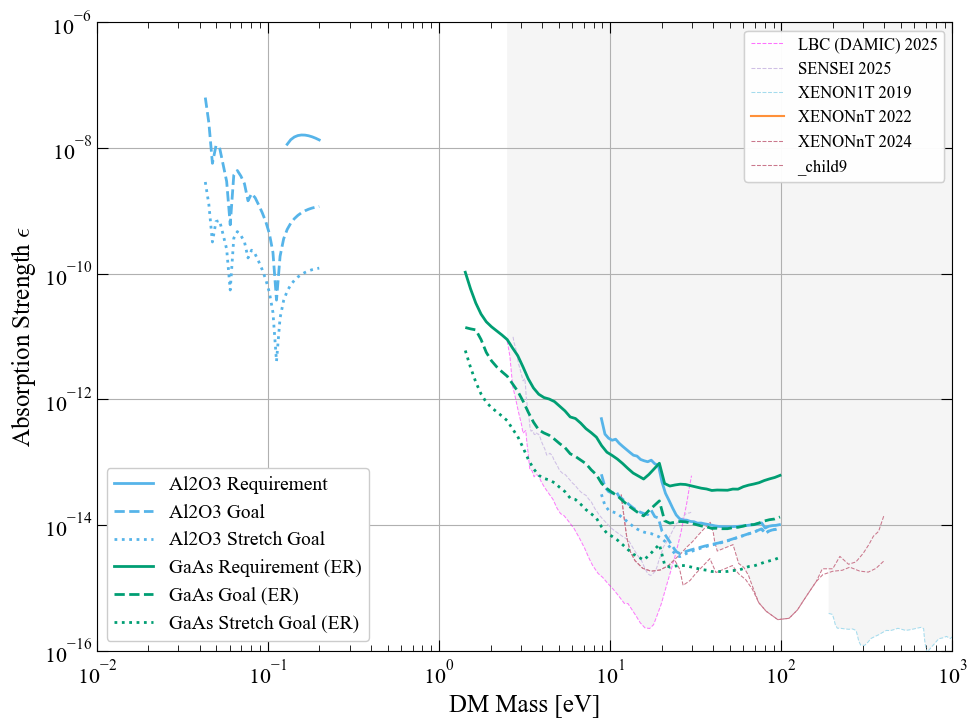

In [12]:
fig, ax, handles_existing = load_and_plot_existing(ER_model='absorption', lw=0.75, leg=False)

handles_calculated = []
m_print_sapphire = 198e-12 # 198e-12 GeV = 198 meV
m_print_gaas = 2e-9 # 2e-9 GeV = 2 eV
GatewayReviewPath = get_cache_path("data/2025_CDR_review_results/")
m_lim, x_lim = np.loadtxt(GatewayReviewPath+'/sapphire_requirement_absorption/limit.txt', unpack=True)
l, = ax.plot(m_lim*1e9, x_lim, '-', color='#56B4E9', lw=2, label='Al2O3 Requirement')
handles_calculated.append(l)
print(f'Sapphire absorption requirement: epsilon at 200 meV = {np.interp(m_print_sapphire, m_lim, x_lim):.2e}')

m_lim, x_lim = np.loadtxt(GatewayReviewPath+'/sapphire_goal_absorption/limit.txt', unpack=True)
l, = ax.plot(m_lim*1e9, x_lim, '--', color='#56B4E9', lw=2, label='Al2O3 Goal')
handles_calculated.append(l)
print(f'Sapphire absorption goal: epsilon at 200 meV = {np.interp(m_print_sapphire, m_lim, x_lim):.2e}')

m_lim, x_lim = np.loadtxt(GatewayReviewPath+'/sapphire_stretch_absorption/limit.txt', unpack=True)
l, = ax.plot(m_lim*1e9, x_lim, ':', color='#56B4E9', lw=2, label='Al2O3 Stretch Goal')
handles_calculated.append(l)
print(f'Sapphire absorption stretch goal: epsilon at 200 meV = {np.interp(m_print_sapphire, m_lim, x_lim):.2e}')

m_lim, x_lim = np.loadtxt(GatewayReviewPath+'/gaas_requirement_ER/results_absorption/limit.txt', unpack=True)
l, = ax.plot(m_lim*1e9, x_lim, '-', color='#009E73', lw=2, label='GaAs Requirement (ER)')
handles_calculated.append(l)
print(f'GaAs absorption requirement: epsilon at 2 eV = {np.interp(m_print_gaas, m_lim, x_lim):.2e}')

# m_lim, x_lim = np.loadtxt(GatewayReviewPath+'/gaas_requirement_NR/results_absorption/limit.txt', unpack=True)
# l, = ax.plot(m_lim*1e9, x_lim, '-', color='y', lw=2, label='GaAs NR Requirement')
# handles_calculated.append(l)

m_lim, x_lim = np.loadtxt(GatewayReviewPath+'/gaas_goal_ER/results_absorption/limit.txt', unpack=True)
l, = ax.plot(m_lim*1e9, x_lim, '--', color='#009E73', lw=2, label='GaAs Goal (ER)')
handles_calculated.append(l)
print(f'GaAs absorption goal: epsilon at 2 eV = {np.interp(m_print_gaas, m_lim, x_lim):.2e}')

# m_lim, x_lim = np.loadtxt(GatewayReviewPath+'/gaas_goal_NR/results_absorption/limit.txt', unpack=True)
# l, = ax.plot(m_lim*1e9, x_lim, '--', color='y', lw=2, label='GaAs NR Goal')
# handles_calculated.append(l)

m_lim, x_lim = np.loadtxt(GatewayReviewPath+'/gaas_stretch/results_absorption/limit.txt', unpack=True)
l, = ax.plot(m_lim*1e9, x_lim, ':', color='#009E73', lw=2, label='GaAs Stretch Goal (ER)')
handles_calculated.append(l)
print(f'GaAs absorption stretch goal: epsilon at 2 eV = {np.interp(m_print_gaas, m_lim, x_lim):.2e}')

leg1 = ax.legend(handles=handles_calculated, loc='lower left', fontsize=14, frameon=True, framealpha=1)
ax.add_artist(leg1)

leg2 = ax.legend(handles=handles_existing, loc='upper right', fontsize=12, frameon=True)
ax.add_artist(leg2)

ax.grid('on')
ax.set_xlim([1e-2, 1e3])
ax.set_ylim([1e-16, 1e-6])
ax.set_xlabel(r'DM Mass [eV]', fontsize=18)
ax.set_ylabel(r'Absorption Strength $\epsilon$', fontsize=18)

fig.tight_layout()
#fig.savefig(GatewayReviewPath+'/TESSERACT_Sensitivities_Absorption.pdf')
fig.show()

GaAs requirement: 7.23e-37 cm^2 at 10 MeV/c^2
GaAs goal: 1.05e-38 cm^2 at 10 MeV/c^2
GaAs stretch goal: 1.76e-39 cm^2 at 10 MeV/c^2

Sapphire requirement: 2.30e-07 cm^2 at 0.1 MeV/c^2
Sapphire goal: 1.62e-30 cm^2 at 0.1 MeV/c^2
Sapphire stretch goal: 2.72e-32 cm^2 at 0.1 MeV/c^2


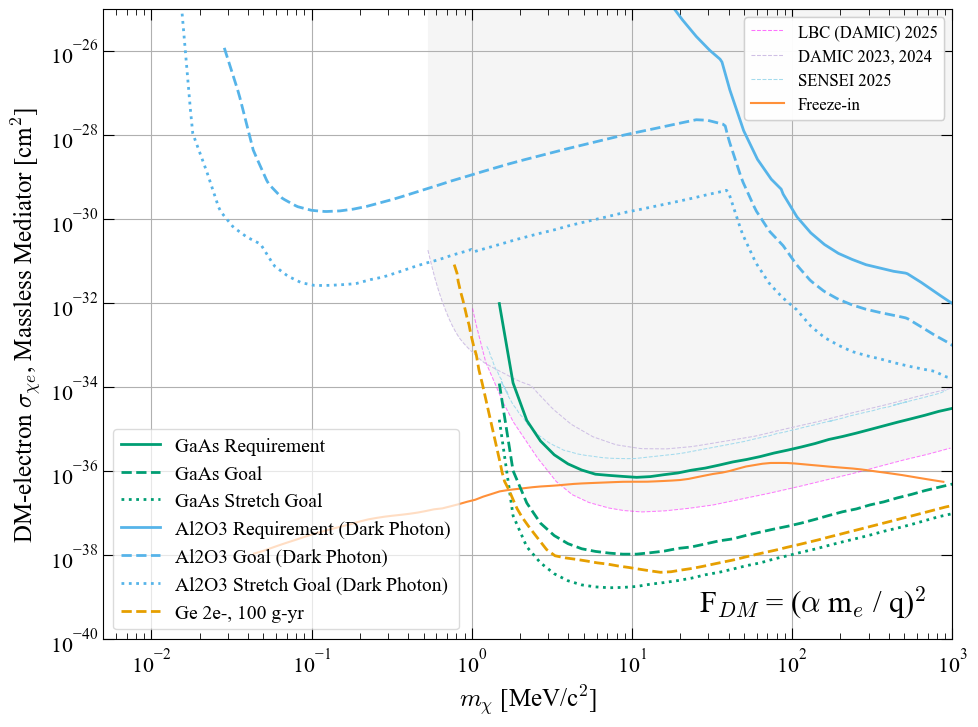

In [16]:
fig, ax, handles_existing = load_and_plot_existing(ER_model='massless', lw=0.75, leg=False)
m_print_gaas = 10e-3 # 10e-3 GeV = 10 MeV
m_print_sapphire = 100e-6 # 100e-6 GeV = 100 keV
handles_calculated = []

m_lim, x_lim = np.loadtxt(GatewayReviewPath+'/gaas_requirement_ER/results_massless_PD_1.24_GaAs_3.0/limit.txt', unpack=True)
l, = ax.plot(m_lim*1e3, x_lim, lw=2, color='#009E73', linestyle='-', label='GaAs Requirement')
handles_calculated.append(l)
print(f'GaAs requirement: {np.interp(m_print_gaas, m_lim, x_lim):.2e} cm^2 at {m_print_gaas*1e3:.0f} MeV/c^2')

m_lim, x_lim = np.loadtxt(GatewayReviewPath+'/gaas_goal_ER/results_massless_PD_1.25_GaAs_3.0/limit.txt', unpack=True)
l, = ax.plot(m_lim*1e3, x_lim, lw=2, color='#009E73', linestyle='--', label='GaAs Goal')
handles_calculated.append(l)
print(f'GaAs goal: {np.interp(m_print_gaas, m_lim, x_lim):.2e} cm^2 at {m_print_gaas*1e3:.0f} MeV/c^2')

m_lim, x_lim = np.loadtxt(GatewayReviewPath+'/gaas_stretch/results_massless_PD_1.29_GaAs_3.0/limit.txt', unpack=True)
l, = ax.plot(m_lim*1e3, x_lim, lw=2, color='#009E73', linestyle=':', label='GaAs Stretch Goal')
handles_calculated.append(l)
print(f'GaAs stretch goal: {np.interp(m_print_gaas, m_lim, x_lim):.2e} cm^2 at {m_print_gaas*1e3:.0f} MeV/c^2')
print('')

m_lim, x_lim = np.loadtxt(GatewayReviewPath+'/sapphire_requirement_darkphoton_massless/combined_results.txt', unpack=True)
l, = ax.plot(m_lim*1e3, x_lim, lw=2, color='#56B4E9', linestyle='-', label='Al2O3 Requirement (Dark Photon)')
handles_calculated.append(l)
print(f'Sapphire requirement: {np.interp(m_print_sapphire, m_lim, x_lim):.2e} cm^2 at {m_print_sapphire*1e3:.1f} MeV/c^2')

m_lim, x_lim = np.loadtxt(GatewayReviewPath+'/sapphire_goal_darkphoton_massless/combined_results.txt', unpack=True)
l, = ax.plot(m_lim*1e3, x_lim, lw=2, color='#56B4E9', linestyle='--', label='Al2O3 Goal (Dark Photon)')
handles_calculated.append(l)
print(f'Sapphire goal: {np.interp(m_print_sapphire, m_lim, x_lim):.2e} cm^2 at {m_print_sapphire*1e3:.1f} MeV/c^2')

m_lim, x_lim = np.loadtxt(GatewayReviewPath+'/sapphire_stretch_darkphoton_massless/combined_results.txt', unpack=True)
l, = ax.plot(m_lim*1e3, x_lim, lw=2, color='#56B4E9', linestyle=':', label='Al2O3 Stretch Goal (Dark Photon)')
handles_calculated.append(l)
print(f'Sapphire stretch goal: {np.interp(m_print_sapphire, m_lim, x_lim):.2e} cm^2 at {m_print_sapphire*1e3:.1f} MeV/c^2')

m_lim, x_lim = np.loadtxt(get_cache_path('data/2025_preCDR_results/Ge_massless.txt'), unpack=True)
l, = ax.plot(m_lim, x_lim, lw=2, color='#E69F00', linestyle='--', label='Ge 2e-, 100 g-yr')
handles_calculated.append(l)

ax.text(0.97, 0.03, r'F$_{DM}$ = ($\alpha$ m$_e$ / q)$^2$', fontsize=22, transform=ax.transAxes, ha='right', va='bottom')

ax.set_xlim([5e-3, 1e3])
ax.set_ylim([1e-40, 1e-25])
ax.set_xlabel(r'$m_\chi$ [MeV/c$^2$]', fontsize=18)
ax.set_ylabel(r'DM-electron $\sigma_{\chi e}$, Massless Mediator [cm$^2$]', fontsize=18)

ax.grid('on')
leg1 = ax.legend(handles=handles_calculated, loc='lower left', fontsize=14, frameon=True, ncol=1, framealpha=0.7)
ax.add_artist(leg1)
leg2 = ax.legend(handles=handles_existing, loc='upper right', fontsize=12, frameon=True)
ax.add_artist(leg2)

fig.tight_layout()
#fig.savefig(GatewayReviewPath+'/TESSERACT_Sensitivities_ER_Massless.pdf')
fig.show()

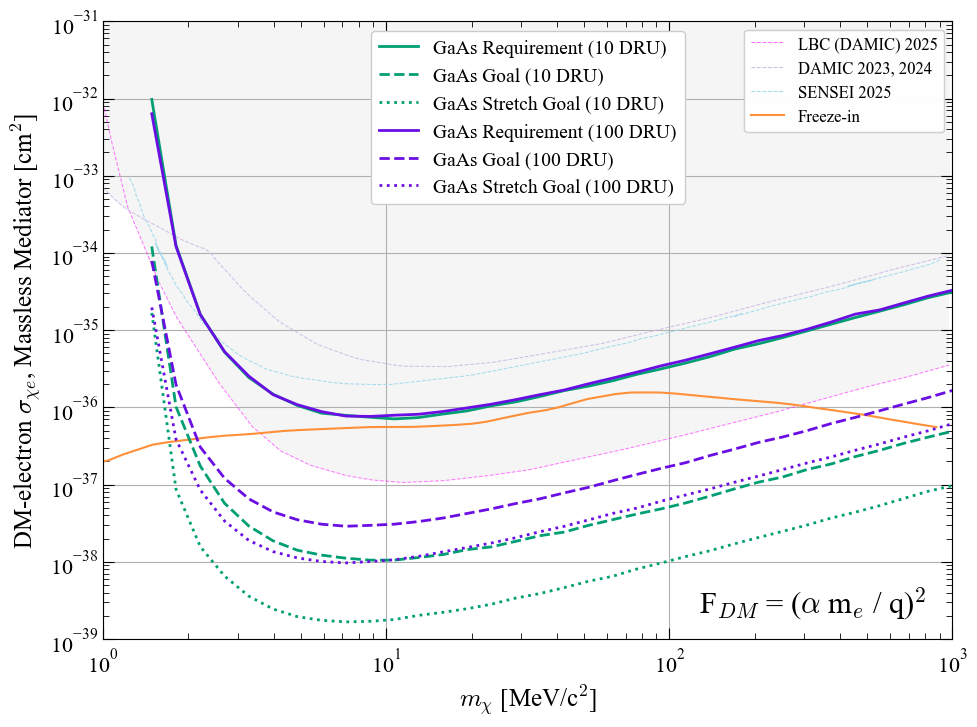

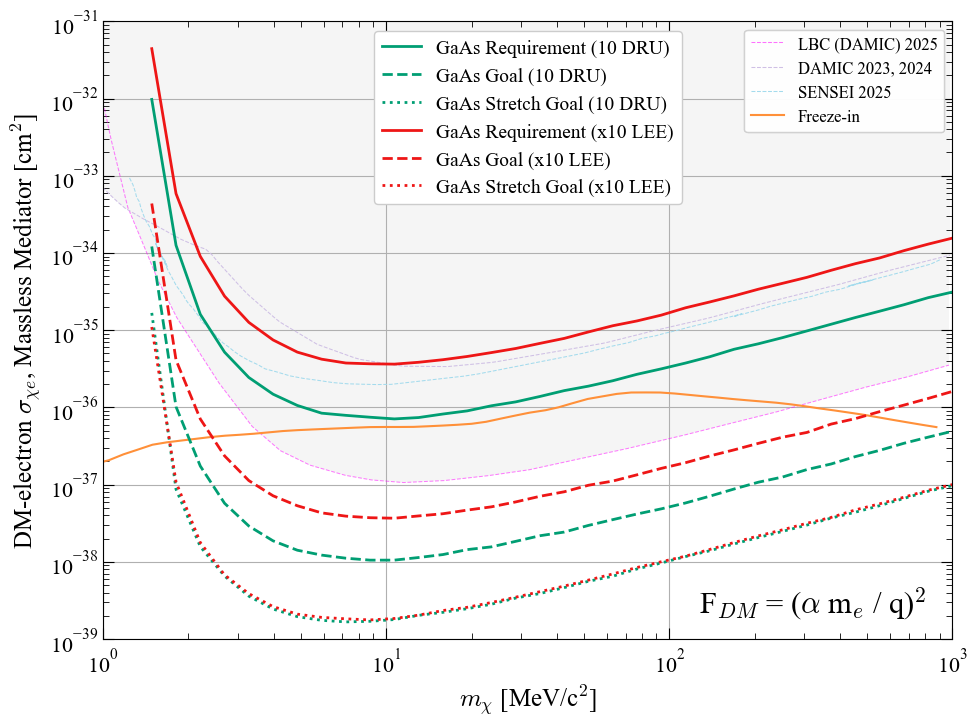

In [17]:
fig, ax, handles_existing = load_and_plot_existing(ER_model='massless', lw=0.75, leg=False)
m_print_gaas = 10e-3 # 10e-3 GeV = 10 MeV
m_print_sapphire = 100e-6 # 100e-6 GeV = 100 keV
handles_calculated = []

m_lim, x_lim = np.loadtxt(GatewayReviewPath+'/gaas_requirement_ER/results_massless_PD_1.24_GaAs_3.0/limit.txt', unpack=True)
l, = ax.plot(m_lim*1e3, x_lim, lw=2, color='#009E73', linestyle='-', label='GaAs Requirement (10 DRU)')
handles_calculated.append(l)

m_lim, x_lim = np.loadtxt(GatewayReviewPath+'/gaas_goal_ER/results_massless_PD_1.25_GaAs_3.0/limit.txt', unpack=True)
l, = ax.plot(m_lim*1e3, x_lim, lw=2, color='#009E73', linestyle='--', label='GaAs Goal (10 DRU)')
handles_calculated.append(l)

m_lim, x_lim = np.loadtxt(GatewayReviewPath+'/gaas_stretch/results_massless_PD_1.29_GaAs_3.0/limit.txt', unpack=True)
l, = ax.plot(m_lim*1e3, x_lim, lw=2, color='#009E73', linestyle=':', label='GaAs Stretch Goal (10 DRU)')
handles_calculated.append(l)

m_lim, x_lim = np.loadtxt(GatewayReviewPath+'/gaas_requirement_ER_10x_DRU/results_massless_PD_1.24_GaAs_3.0/limit.txt', unpack=True)
l, = ax.plot(m_lim*1e3, x_lim, lw=2, color="#6A0EE3", linestyle='-', label='GaAs Requirement (100 DRU)')
handles_calculated.append(l)

m_lim, x_lim = np.loadtxt(GatewayReviewPath+'/gaas_goal_ER_10x_DRU/results_massless_PD_1.25_GaAs_3.0/limit.txt', unpack=True)
l, = ax.plot(m_lim*1e3, x_lim, lw=2, color='#6A0EE3', linestyle='--', label='GaAs Goal (100 DRU)')
handles_calculated.append(l)

m_lim, x_lim = np.loadtxt(GatewayReviewPath+'/gaas_stretch_10x_DRU/results_massless_PD_1.29_GaAs_3.0/limit.txt', unpack=True)
l, = ax.plot(m_lim*1e3, x_lim, lw=2, color='#6A0EE3', linestyle=':', label='GaAs Stretch Goal (100 DRU)')
handles_calculated.append(l)

ax.text(0.97, 0.03, r'F$_{DM}$ = ($\alpha$ m$_e$ / q)$^2$', fontsize=22, transform=ax.transAxes, ha='right', va='bottom')

ax.set_xlim([1e0, 1e3])
ax.set_ylim([1e-39, 1e-31])
ax.set_xlabel(r'$m_\chi$ [MeV/c$^2$]', fontsize=18)
ax.set_ylabel(r'DM-electron $\sigma_{\chi e}$, Massless Mediator [cm$^2$]', fontsize=18)

ax.grid('on')
leg1 = ax.legend(handles=handles_calculated, loc='upper center', fontsize=14, frameon=True, ncol=1, framealpha=1)
ax.add_artist(leg1)
leg2 = ax.legend(handles=handles_existing, loc='upper right', fontsize=12, frameon=True)
ax.add_artist(leg2)

fig.tight_layout()
fig.show()

#################################################

fig, ax, handles_existing = load_and_plot_existing(ER_model='massless', lw=0.75, leg=False)
m_print_gaas = 10e-3 # 10e-3 GeV = 10 MeV
m_print_sapphire = 100e-6 # 100e-6 GeV = 100 keV
handles_calculated = []

m_lim, x_lim = np.loadtxt(GatewayReviewPath+'/gaas_requirement_ER/results_massless_PD_1.24_GaAs_3.0/limit.txt', unpack=True)
l, = ax.plot(m_lim*1e3, x_lim, lw=2, color='#009E73', linestyle='-', label='GaAs Requirement (10 DRU)')
handles_calculated.append(l)

m_lim, x_lim = np.loadtxt(GatewayReviewPath+'/gaas_goal_ER/results_massless_PD_1.25_GaAs_3.0/limit.txt', unpack=True)
l, = ax.plot(m_lim*1e3, x_lim, lw=2, color='#009E73', linestyle='--', label='GaAs Goal (10 DRU)')
handles_calculated.append(l)

m_lim, x_lim = np.loadtxt(GatewayReviewPath+'/gaas_stretch/results_massless_PD_1.29_GaAs_3.0/limit.txt', unpack=True)
l, = ax.plot(m_lim*1e3, x_lim, lw=2, color='#009E73', linestyle=':', label='GaAs Stretch Goal (10 DRU)')
handles_calculated.append(l)

m_lim, x_lim = np.loadtxt(GatewayReviewPath+'/gaas_requirement_ER_10x_LEE/results_massless_PD_1.24_GaAs_3.0/limit.txt', unpack=True)
l, = ax.plot(m_lim*1e3, x_lim, lw=2, color="#EE1616", linestyle='-', label='GaAs Requirement (x10 LEE)')
handles_calculated.append(l)

m_lim, x_lim = np.loadtxt(GatewayReviewPath+'/gaas_goal_ER_10x_LEE/results_massless_PD_1.25_GaAs_3.0/limit.txt', unpack=True)
l, = ax.plot(m_lim*1e3, x_lim, lw=2, color="#EE1616", linestyle='--', label='GaAs Goal (x10 LEE)')
handles_calculated.append(l)

m_lim, x_lim = np.loadtxt(GatewayReviewPath+'/gaas_stretch_10x_LEE/results_massless_PD_1.29_GaAs_3.0/limit.txt', unpack=True)
l, = ax.plot(m_lim*1e3, x_lim, lw=2, color="#EE1616", linestyle=':', label='GaAs Stretch Goal (x10 LEE)')
handles_calculated.append(l)

ax.text(0.97, 0.03, r'F$_{DM}$ = ($\alpha$ m$_e$ / q)$^2$', fontsize=22, transform=ax.transAxes, ha='right', va='bottom')

ax.set_xlim([1e0, 1e3])
ax.set_ylim([1e-39, 1e-31])
ax.set_xlabel(r'$m_\chi$ [MeV/c$^2$]', fontsize=18)
ax.set_ylabel(r'DM-electron $\sigma_{\chi e}$, Massless Mediator [cm$^2$]', fontsize=18)

ax.grid('on')
leg1 = ax.legend(handles=handles_calculated, loc='upper center', fontsize=14, frameon=True, ncol=1, framealpha=1)
ax.add_artist(leg1)
leg2 = ax.legend(handles=handles_existing, loc='upper right', fontsize=12, frameon=True)
ax.add_artist(leg2)

fig.tight_layout()
fig.show()

In [6]:
# m_lim, x_lim = np.loadtxt('required_performance_ER_like/projection_300d_3fold_massless/limit.txt', unpack=True)
# l, = ax.plot(m_lim*1e3, x_lim, lw=2, color='#009E73', linestyle='-', label='GaAs Requirement (3-fold)')
# handles_calculated.append(l)

# m_lim, x_lim = np.loadtxt('goal_performance_ER_like/projection_300d_3fold_massless/limit.txt', unpack=True)
# l, = ax.plot(m_lim*1e3, x_lim, lw=2, color='#009E73', linestyle='--', label='GaAs Goal (3-fold)')
# handles_calculated.append(l)

# m_lim, x_lim = np.loadtxt('stretch_performance_ER_like/projection_300d_3fold_massless/limit.txt', unpack=True)
# l, = ax.plot(m_lim*1e3, x_lim, lw=2, color='#009E73', linestyle=':', label='GaAs Stretch Goal (3-fold)')
# handles_calculated.append(l)


# m_lim, x_lim = np.loadtxt('gaas_exploration/base_reqlike_50LCE_2PD/limit.txt', unpack=True)
# l, = ax.plot(m_lim*1e3, x_lim, lw=2, color='#FF0000', linestyle='-', label='Two PDs, LCE = 50%, no LEE')
# handles_calculated.append(l)

# m_lim, x_lim = np.loadtxt('gaas_exploration/base_reqlike_25LCE_2PD/limit.txt', unpack=True)
# l, = ax.plot(m_lim*1e3, x_lim, lw=2, color="#FF0000", linestyle='--', label='Two PDs, LCE = 25%, no LEE')
# handles_calculated.append(l)

# m_lim, x_lim = np.loadtxt('gaas_exploration/base_reqlike_LEE_div_10/limit.txt', unpack=True)
# l, = ax.plot(m_lim*1e3, x_lim, lw=2, color="#0000FF", linestyle='-', label='One PD, LCE = 25%, LEE/10 per sensor')
# handles_calculated.append(l)

# m_lim, x_lim = np.loadtxt('gaas_exploration/base_reqlike_LEE_div_20/limit.txt', unpack=True)
# l, = ax.plot(m_lim*1e3, x_lim, lw=2, color="#0000FF", linestyle='--', label='One PD, LCE = 25%, LEE/20 per sensor')
# handles_calculated.append(l)

# m_lim, x_lim = np.loadtxt('gaas_exploration/base_reqlike_LEE_div_40/limit.txt', unpack=True)
# l, = ax.plot(m_lim*1e3, x_lim, lw=2, color="#0000FF", linestyle='-.', label='One PD, LCE = 25%, LEE/40 per sensor')
# handles_calculated.append(l)

# m_lim, x_lim = np.loadtxt('gaas_exploration/base_reqlike_LEE_div_40_LCE50/limit.txt', unpack=True)
# l, = ax.plot(m_lim*1e3, x_lim, lw=2, color="#0000FF", linestyle=':', label='One PD, LCE = 50%, LEE/40 per sensor')
# handles_calculated.append(l)

# m_lim, x_lim = np.loadtxt('gaas_exploration/base_reqlike_no_LEE/limit.txt', unpack=True)
# l, = ax.plot(m_lim*1e3, x_lim, lw=2, color="#000000", linestyle='-', label='One PD, LCE = 50%, No LEE')
# handles_calculated.append(l)

# m_lim, x_lim = np.loadtxt('gaas_exploration/even_larger/base/limit.txt', unpack=True)
# l, = ax.plot(m_lim*1e3, x_lim, lw=2, color="#000000", linestyle='-', label='Base with two PDs (2 cm^3 GaAs, 1 eV_GaAs threshold, LCE = 25%)')
# handles_calculated.append(l)

# m_lim, x_lim = np.loadtxt('gaas_exploration/even_larger/lower_GaAs_threshold/limit.txt', unpack=True)
# l, = ax.plot(m_lim*1e3, x_lim, lw=2, color="#000000", linestyle='--', label='Decrease GaAs threshold to 0.75 eV')
# handles_calculated.append(l)

# m_lim, x_lim = np.loadtxt('gaas_exploration/even_larger/LCE_50pct/limit.txt', unpack=True)
# l, = ax.plot(m_lim*1e3, x_lim, lw=2, color="#000000", linestyle=':', label='Increase LCE to 50%')
# handles_calculated.append(l)

# m_lim, x_lim = np.loadtxt('gaas_exploration/even_larger/no_LEE/limit.txt', unpack=True)
# l, = ax.plot(m_lim*1e3, x_lim, lw=2, color="#000000", linestyle='-.', label='LEE-free')
# handles_calculated.append(l)

# m_lim, x_lim = np.loadtxt('gaas_exploration/even_larger/base_2x_size/limit.txt', unpack=True)
# l, = ax.plot(m_lim*1e3, x_lim, lw=2, color="#FF0000", linestyle='-.', label='4 cm^3 GaAs, 25% LCE, two PDs (est.)')
# handles_calculated.append(l)

# m_lim, x_lim = np.loadtxt('gaas_exploration/even_larger/base_4x_size/limit.txt', unpack=True)
# l, = ax.plot(m_lim*1e3, x_lim, lw=2, color="#00FF00", linestyle='-.', label='8 cm^3 GaAs, 25% LCE, two PDs (est.)')
# handles_calculated.append(l)

# m_lim, x_lim = np.loadtxt('gaas_exploration/even_larger/base_2fold/limit.txt', unpack=True)
# l, = ax.plot(m_lim*1e3, x_lim, lw=2, color="#0000FF", linestyle='-', label='Base with one PD  (2 cm^3 GaAs, 1 eV_GaAs threshold, LCE = 25%)')
# handles_calculated.append(l)

# m_lim, x_lim = np.loadtxt('gaas_exploration/even_larger/LCE_50pct_2fold/limit.txt', unpack=True)
# l, = ax.plot(m_lim*1e3, x_lim, lw=2, color="#0000FF", linestyle=':', label='One PD, Increase LCE to 50%')
# handles_calculated.append(l)

# m_lim, x_lim = np.loadtxt('gaas_exploration/even_larger/no_lee_2fold/limit.txt', unpack=True)
# l, = ax.plot(m_lim*1e3, x_lim, lw=2, color="#0000FF", linestyle='-.', label='One PD, LEE-free')
# handles_calculated.append(l)

# colors = ['#1f77b4',  # blue
#           '#9467bd',  # purple
#           '#2ca02c',  # green
#           '#d62728']  # red
# linestyles = ['-', '--', '-.', ':']

# for i, E_th_PD in enumerate([1.0, 1.1, 1.2, 1.3]):
#     for j, E_th_GaAs in enumerate([1.5, 2.0, 2.5, 3.0]):

#         try:
#             m_lim, x_lim = np.loadtxt(f'gaas_exploration/higher_scintillation_xsmall/gamma_energy_1.3/results_3fold_PD_{E_th_PD}eV_GaAs_{E_th_GaAs}eV/limit.txt', unpack=True)
#             # m_lim, x_lim = np.loadtxt(f'gaas_exploration/higher_scintillation_large/gamma_energy_1.3/combined_results_2fold_PD_{E_th_PD}eV_GaAs_{E_th_GaAs}eV.txt', unpack=True)
#             l, = ax.plot(m_lim*1e3, x_lim, lw=1, color=colors[i], linestyle=linestyles[j], label=f'PD {E_th_PD} eV, GaAs {E_th_GaAs} eV')
#             handles_calculated.append(l)
#         except FileNotFoundError:
#             pass

# colors = ['#E6194B', '#F58231', '#FFE119', '#BFEF45', '#3CB44B', '#42D4F4', '#4363D8', '#911EB4', '#F032E6',  "#872E2E", '#A9A9A9']

# for i, volume in enumerate(np.arange(0.8, 8.1, 0.8)):
#     try:
#         m_lim, x_lim = np.loadtxt(f'test_volume_{volume:.1f}cm3/limit.txt', unpack=True)
#         l, = ax.plot(m_lim*1e3, x_lim, lw=2, color=colors[i], linestyle='-', label=f'Thickness = {(volume/8):.1f} cm')
#         handles_calculated.append(l)
#     except FileNotFoundError:
#         print(f'File for volume {volume:.1f} cm^3 not found.')

# for i, E_th in enumerate(np.arange(1, 1.4, 0.1)):
#     try:
#         m_lim, x_lim = np.loadtxt(f'test_E_th_PD_{E_th:.1f}/limit.txt', unpack=True)
#         l, = ax.plot(m_lim*1e3, x_lim, lw=2, color=colors[i], linestyle='-', label=f'E_th_PD = {E_th:.1f} eV')
#         handles_calculated.append(l)
#     except FileNotFoundError:
#         print(f'File for E_th_PD = {E_th:.1f} eV not found.')

# for i, E_th in enumerate(np.arange(1.1, 1.4, 0.1)):
#     try:
#         m_lim, x_lim = np.loadtxt(f'gaas_exploration/higher_scintillation_evensmaller/results_E_th_PD_{E_th:.1f}/limit.txt', unpack=True)
#         l, = ax.plot(m_lim*1e3, x_lim, lw=2, color=colors[i+6], linestyle='--', label=f'E_th_PD = {E_th:.1f} eV')
#         handles_calculated.append(l)
#     except FileNotFoundError:
#         print(f'File for E_th_PD = {E_th:.1f} eV not found here.')


# # m_lim = np.array([1., 2.15443469, 4.64158883, 10., 21.5443469, 46.41588834, 100., 215.443469, 464.15888336, 1000.])
# # x_lim = np.array([np.inf, 5.11317186e-35, 2.84229796e-36, 1.81499803e-36,
# #                   2.42090976e-36, 4.23433238e-36, 8.33222003e-36, 1.71466494e-35,
# #                   3.62020411e-35, 7.71317621e-35])
# l, = ax.plot(m_lim, x_lim, lw=2, color='blue', linestyle='-', label='Feldman-Cousins, E_th_PD = 1 eV')
# handles_calculated.append(l)

# m_lim, x_lim = np.loadtxt(f'gaas_exploration/higher_scintillation_xsmall/gamma_energy_1.3/results_3fold_PD_{1.0}eV_GaAs_{3.0}eV/limit.txt', unpack=True)
# l, = ax.plot(m_lim*1e3, x_lim, lw=3, color=colors[1], label=f'Extra-Small (3-fold)')
# handles_calculated.append(l)

# m_lim, x_lim = np.loadtxt(f'gaas_exploration/higher_scintillation_small/gamma_energy_1.3/results_3fold_PD_{1.1}eV_GaAs_{5.0}eV/limit.txt', unpack=True)
# l, = ax.plot(m_lim*1e3, x_lim, lw=3, color=colors[3], label=f'Small (3-fold)')
# handles_calculated.append(l)

# m_lim, x_lim = np.loadtxt(f'gaas_exploration/higher_scintillation_small/gamma_energy_1.3/combined_results_2fold_PD_{1.3}eV_GaAs_{5.0}eV.txt', unpack=True)
# l, = ax.plot(m_lim*1e3, x_lim, lw=3, color=colors[3], linestyle='--', label=f'Small (2-fold)')
# handles_calculated.append(l)

# m_lim, x_lim = np.loadtxt(f'gaas_exploration/higher_scintillation_medium/gamma_energy_1.3/results_3fold_PD_{1.1}eV_GaAs_{3.0}eV/limit.txt', unpack=True)
# l, = ax.plot(m_lim*1e3, x_lim, lw=3, color=colors[0], label=f'Medium (3-fold)')
# handles_calculated.append(l)

# m_lim, x_lim = np.loadtxt(f'gaas_exploration/higher_scintillation_medium/gamma_energy_1.3/combined_results_2fold_PD_{1.3}eV_GaAs_{5.0}eV.txt', unpack=True)
# l, = ax.plot(m_lim*1e3, x_lim, lw=3, color=colors[0], linestyle='--', label=f'Medium (2-fold)')
# handles_calculated.append(l)

# m_lim, x_lim = np.loadtxt(f'gaas_exploration/higher_scintillation_large/gamma_energy_1.3/combined_results_3fold.txt', unpack=True)
# l, = ax.plot(m_lim*1e3, x_lim, lw=3, color=colors[2], label=f'Large (3-fold)')
# handles_calculated.append(l)

# m_lim, x_lim = np.loadtxt(f'gaas_exploration/higher_scintillation_large/gamma_energy_1.3/combined_results_2fold_PD_{1.3}eV_GaAs_{5.0}eV.txt', unpack=True)
# l, = ax.plot(m_lim*1e3, x_lim, lw=3, color=colors[2], linestyle='--', label=f'Large (2-fold)')
# handles_calculated.append(l)

# m_lim, x_lim = np.loadtxt(f'gaas_exploration/all_background_free/ER_requirement_massless/limit.txt', unpack=True)
# l, = ax.plot(m_lim*1e3, x_lim, lw=2, color='#009E73', linestyle='-', label='GaAs Requirement')
# handles_calculated.append(l)

# m_lim, x_lim = np.loadtxt(f'gaas_exploration/all_background_free/ER_goal_massless/limit.txt', unpack=True)
# l, = ax.plot(m_lim*1e3, x_lim, lw=2, color='#009E73', linestyle='--', label='GaAs Goal')
# handles_calculated.append(l)

# m_lim, x_lim = np.loadtxt(f'gaas_exploration/all_background_free/ER_stretch_massless/limit.txt', unpack=True)
# l, = ax.plot(m_lim*1e3, x_lim, lw=2, color='#009E73', linestyle=':', label='GaAs Stretch Goal')
# handles_calculated.append(l)



GaAs requirement: 7.91e-38 cm^2 at 10 MeV/c^2
GaAs goal: 1.35e-39 cm^2 at 10 MeV/c^2
GaAs stretch: 2.91e-40 cm^2 at 10 MeV/c^2

Sapphire requirement: 1.90e-42 cm^2 at 1.0 MeV/c^2
Sapphire goal: 2.08e-43 cm^2 at 1.0 MeV/c^2
Sapphire stretch goal: 4.83e-44 cm^2 at 1.0 MeV/c^2


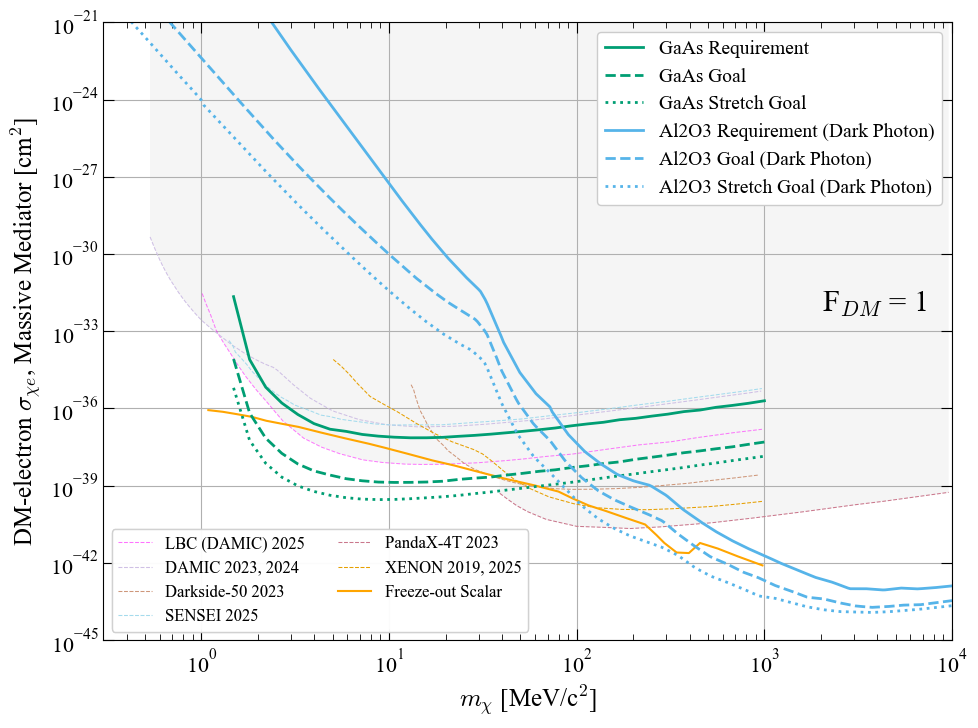

In [18]:
fig, ax, handles_existing = load_and_plot_existing(ER_model='massive', lw=0.75, leg=False)
handles_calculated = []
m_print_GaAs = 10e-3 # 10e-3 GeV = 10 MeV
m_print_sapphire = 1 # 1 GeV

m_lim, x_lim = np.loadtxt(GatewayReviewPath+'/gaas_requirement_ER/results_massive_PD_1.24_GaAs_3.0/limit.txt', unpack=True)
l, = ax.plot(m_lim*1e3, x_lim, lw=2, color='#009E73', linestyle='-', label='GaAs Requirement')
handles_calculated.append(l)
print(f'GaAs requirement: {np.interp(m_print_GaAs, m_lim, x_lim):.2e} cm^2 at {m_print_GaAs*1e3:.0f} MeV/c^2')

m_lim, x_lim = np.loadtxt(GatewayReviewPath+'/gaas_goal_ER/results_massive_PD_1.25_GaAs_3.0/limit.txt', unpack=True)
l, = ax.plot(m_lim*1e3, x_lim, lw=2, color='#009E73', linestyle='--', label='GaAs Goal')
handles_calculated.append(l)
print(f'GaAs goal: {np.interp(m_print_GaAs, m_lim, x_lim):.2e} cm^2 at {m_print_GaAs*1e3:.0f} MeV/c^2')

m_lim, x_lim = np.loadtxt(GatewayReviewPath+'/gaas_stretch/results_massive_PD_1.29_GaAs_3.0/limit.txt', unpack=True)
l, = ax.plot(m_lim*1e3, x_lim, lw=2, color='#009E73', linestyle=':', label='GaAs Stretch Goal')
handles_calculated.append(l)
print(f'GaAs stretch: {np.interp(m_print_GaAs, m_lim, x_lim):.2e} cm^2 at {m_print_GaAs*1e3:.0f} MeV/c^2')
print('')

m_lim, x_lim = np.loadtxt(GatewayReviewPath+'/sapphire_requirement_darkphoton_massive/combined_results.txt', unpack=True)
l, = ax.plot(m_lim*1e3, x_lim, lw=2, color='#56B4E9', linestyle='-', label='Al2O3 Requirement (Dark Photon)')
handles_calculated.append(l)
print(f'Sapphire requirement: {np.interp(m_print_sapphire, m_lim, x_lim):.2e} cm^2 at {m_print_sapphire:.1f} MeV/c^2')

m_lim, x_lim = np.loadtxt(GatewayReviewPath+'/sapphire_goal_darkphoton_massive/combined_results.txt', unpack=True)
l, = ax.plot(m_lim*1e3, x_lim, lw=2, color='#56B4E9', linestyle='--', label='Al2O3 Goal (Dark Photon)')
handles_calculated.append(l)
print(f'Sapphire goal: {np.interp(m_print_sapphire, m_lim, x_lim):.2e} cm^2 at {m_print_sapphire:.1f} MeV/c^2')

m_lim, x_lim = np.loadtxt(GatewayReviewPath+'/sapphire_stretch_darkphoton_massive/combined_results.txt', unpack=True)
l, = ax.plot(m_lim*1e3, x_lim, lw=2, color='#56B4E9', linestyle=':', label='Al2O3 Stretch Goal (Dark Photon)')
handles_calculated.append(l)
print(f'Sapphire stretch goal: {np.interp(m_print_sapphire, m_lim, x_lim):.2e} cm^2 at {m_print_sapphire:.1f} MeV/c^2')

ax.grid('on')
ax.text(0.97, 0.52, r'F$_{DM}$ = 1', fontsize=22, transform=ax.transAxes, ha='right', va='bottom')

leg1 = ax.legend(handles=handles_calculated, loc='upper right', fontsize=14, frameon=True, framealpha=1)
ax.add_artist(leg1)

leg2 = ax.legend(handles=handles_existing, loc='lower left', fontsize=12, frameon=True, ncol=2)
ax.add_artist(leg2)

ax.set_xlim([3e-1, 1e4])
ax.set_ylim([1e-45, 1e-21])
ax.set_xlabel(r'$m_\chi$ [MeV/c$^2$]', fontsize=18)
ax.set_ylabel(r'DM-electron $\sigma_{\chi e}$, Massive Mediator [cm$^2$]', fontsize=18)

fig.tight_layout()
#fig.savefig(GatewayReviewPath+'/TESSERACT_Sensitivities_ER_Massive.pdf')
fig.show()

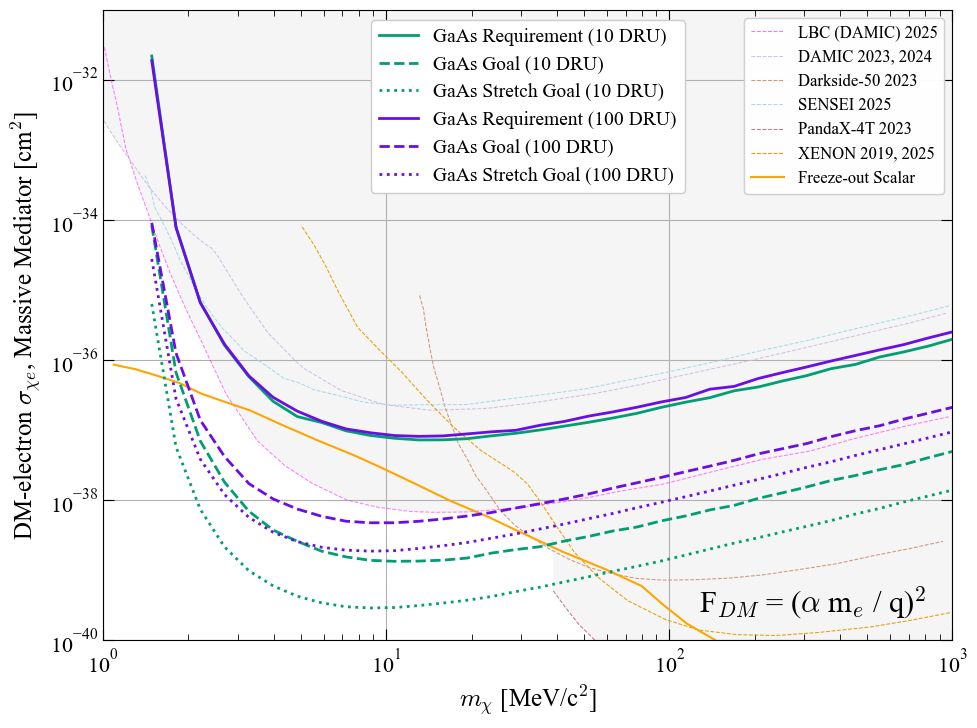

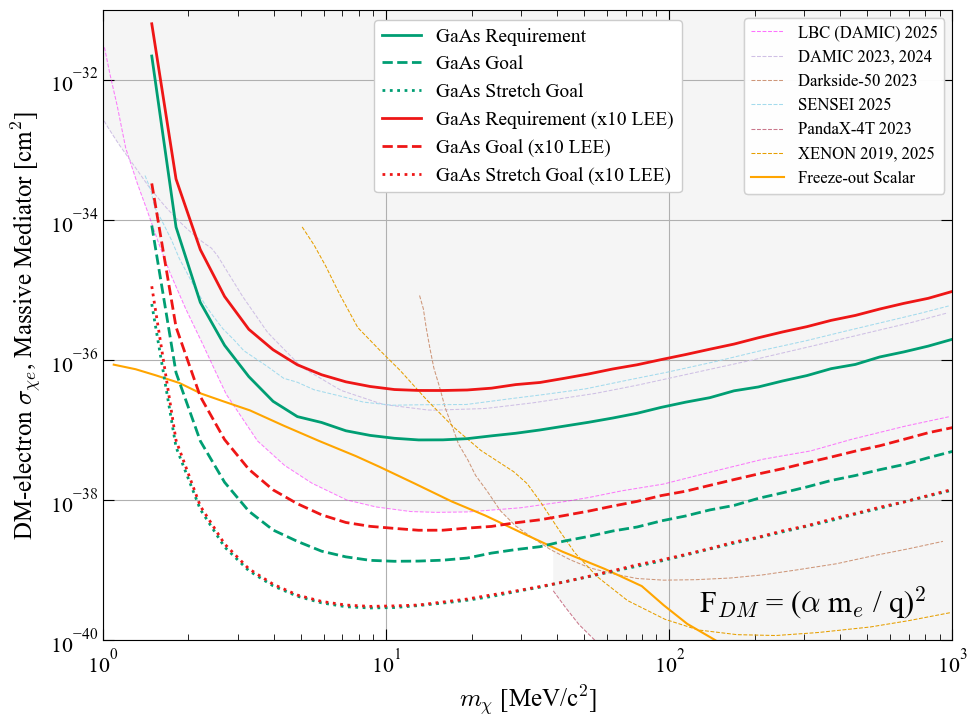

In [19]:
fig, ax, handles_existing = load_and_plot_existing(ER_model='massive', lw=0.75, leg=False)
handles_calculated = []

m_lim, x_lim = np.loadtxt(GatewayReviewPath+'/gaas_requirement_ER/results_massive_PD_1.24_GaAs_3.0/limit.txt', unpack=True)
l, = ax.plot(m_lim*1e3, x_lim, lw=2, color='#009E73', linestyle='-', label='GaAs Requirement (10 DRU)')
handles_calculated.append(l)

m_lim, x_lim = np.loadtxt(GatewayReviewPath+'/gaas_goal_ER/results_massive_PD_1.25_GaAs_3.0/limit.txt', unpack=True)
l, = ax.plot(m_lim*1e3, x_lim, lw=2, color='#009E73', linestyle='--', label='GaAs Goal (10 DRU)')
handles_calculated.append(l)

m_lim, x_lim = np.loadtxt(GatewayReviewPath+'/gaas_stretch/results_massive_PD_1.29_GaAs_3.0/limit.txt', unpack=True)
l, = ax.plot(m_lim*1e3, x_lim, lw=2, color='#009E73', linestyle=':', label='GaAs Stretch Goal (10 DRU)')
handles_calculated.append(l)

m_lim, x_lim = np.loadtxt(GatewayReviewPath+'/gaas_requirement_ER_10x_DRU/results_massive_PD_1.24_GaAs_3.0/limit.txt', unpack=True)
l, = ax.plot(m_lim*1e3, x_lim, lw=2, color="#6A0EE3", linestyle='-', label='GaAs Requirement (100 DRU)')
handles_calculated.append(l)

m_lim, x_lim = np.loadtxt(GatewayReviewPath+'/gaas_goal_ER_10x_DRU/results_massive_PD_1.25_GaAs_3.0/limit.txt', unpack=True)
l, = ax.plot(m_lim*1e3, x_lim, lw=2, color='#6A0EE3', linestyle='--', label='GaAs Goal (100 DRU)')
handles_calculated.append(l)

m_lim, x_lim = np.loadtxt(GatewayReviewPath+'/gaas_stretch_10x_DRU/results_massive_PD_1.29_GaAs_3.0/limit.txt', unpack=True)
l, = ax.plot(m_lim*1e3, x_lim, lw=2, color='#6A0EE3', linestyle=':', label='GaAs Stretch Goal (100 DRU)')
handles_calculated.append(l)

ax.text(0.97, 0.03, r'F$_{DM}$ = ($\alpha$ m$_e$ / q)$^2$', fontsize=22, transform=ax.transAxes, ha='right', va='bottom')

ax.set_xlim([1e0, 1e3])
ax.set_ylim([1e-40, 1e-31])
ax.set_xlabel(r'$m_\chi$ [MeV/c$^2$]', fontsize=18)
ax.set_ylabel(r'DM-electron $\sigma_{\chi e}$, Massive Mediator [cm$^2$]', fontsize=18)

ax.grid('on')
leg1 = ax.legend(handles=handles_calculated, loc='upper center', fontsize=14, frameon=True, ncol=1, framealpha=1)
ax.add_artist(leg1)
leg2 = ax.legend(handles=handles_existing, loc='upper right', fontsize=12, frameon=True)
ax.add_artist(leg2)

fig.tight_layout()
fig.show()

##############################

fig, ax, handles_existing = load_and_plot_existing(ER_model='massive', lw=0.75, leg=False)
handles_calculated = []

m_lim, x_lim = np.loadtxt(GatewayReviewPath+'/gaas_requirement_ER/results_massive_PD_1.24_GaAs_3.0/limit.txt', unpack=True)
l, = ax.plot(m_lim*1e3, x_lim, lw=2, color='#009E73', linestyle='-', label='GaAs Requirement')
handles_calculated.append(l)

m_lim, x_lim = np.loadtxt(GatewayReviewPath+'/gaas_goal_ER/results_massive_PD_1.25_GaAs_3.0/limit.txt', unpack=True)
l, = ax.plot(m_lim*1e3, x_lim, lw=2, color='#009E73', linestyle='--', label='GaAs Goal')
handles_calculated.append(l)

m_lim, x_lim = np.loadtxt(GatewayReviewPath+'/gaas_stretch/results_massive_PD_1.29_GaAs_3.0/limit.txt', unpack=True)
l, = ax.plot(m_lim*1e3, x_lim, lw=2, color='#009E73', linestyle=':', label='GaAs Stretch Goal')
handles_calculated.append(l)

m_lim, x_lim = np.loadtxt(GatewayReviewPath+'/gaas_requirement_ER_10x_LEE/results_massive_PD_1.24_GaAs_3.0/limit.txt', unpack=True)
l, = ax.plot(m_lim*1e3, x_lim, lw=2, color="#EE1616", linestyle='-', label='GaAs Requirement (x10 LEE)')
handles_calculated.append(l)

m_lim, x_lim = np.loadtxt(GatewayReviewPath+'/gaas_goal_ER_10x_LEE/results_massive_PD_1.25_GaAs_3.0/limit.txt', unpack=True)
l, = ax.plot(m_lim*1e3, x_lim, lw=2, color="#EE1616", linestyle='--', label='GaAs Goal (x10 LEE)')
handles_calculated.append(l)

m_lim, x_lim = np.loadtxt(GatewayReviewPath+'/gaas_stretch_10x_LEE/results_massive_PD_1.29_GaAs_3.0/limit.txt', unpack=True)
l, = ax.plot(m_lim*1e3, x_lim, lw=2, color="#EE1616", linestyle=':', label='GaAs Stretch Goal (x10 LEE)')
handles_calculated.append(l)

ax.text(0.97, 0.03, r'F$_{DM}$ = ($\alpha$ m$_e$ / q)$^2$', fontsize=22, transform=ax.transAxes, ha='right', va='bottom')

ax.set_xlim([1e0, 1e3])
ax.set_ylim([1e-40, 1e-31])
ax.set_xlabel(r'$m_\chi$ [MeV/c$^2$]', fontsize=18)
ax.set_ylabel(r'DM-electron $\sigma_{\chi e}$, Massive Mediator [cm$^2$]', fontsize=18)

ax.grid('on')
leg1 = ax.legend(handles=handles_calculated, loc='upper center', fontsize=14, frameon=True, ncol=1, framealpha=1)
ax.add_artist(leg1)
leg2 = ax.legend(handles=handles_existing, loc='upper right', fontsize=12, frameon=True)
ax.add_artist(leg2)

fig.tight_layout()
fig.show()

In [9]:
# m_lim, x_lim = np.loadtxt('required_performance_ER_like/projection_5d_2fold_massive/limit.txt', unpack=True)
# l, = ax.plot(m_lim*1e3, x_lim, lw=2, color='black', linestyle='-', label='Requirement (2-fold, 300 days)')
# handles_calculated.append(l)

# m_lim, x_lim = np.loadtxt('required_performance_ER_like/projection_300d_3fold_massive/limit.txt', unpack=True)
# l, = ax.plot(m_lim*1e3, x_lim, lw=2, color='#009E73', linestyle='-', label='GaAs Requirement (3-fold)')
# handles_calculated.append(l)
# j = np.argmin(np.abs(m_lim - 10e-3))
# print(f"GaAs Requirement: {m_lim[j]*1e3:.2f} MeV/c^2, {x_lim[j]:.2e} cm^2")

# m_lim, x_lim = np.loadtxt('goal_performance_ER_like/projection_10d_2fold_massive/limit.txt', unpack=True)
# l, = ax.plot(m_lim*1e3, x_lim, lw=2, color='blue', linestyle='-', label='Goal (2-fold, 300 days)')
# handles_calculated.append(l)

# m_lim, x_lim = np.loadtxt('goal_performance_ER_like/projection_300d_3fold_massive/limit.txt', unpack=True)
# l, = ax.plot(m_lim*1e3, x_lim, lw=2, color='#009E73', linestyle='--', label='GaAs Goal (3-fold)')
# handles_calculated.append(l)
# j = np.argmin(np.abs(m_lim - 10e-3))
# print(f"GaAs Goal: {m_lim[j]*1e3:.2f} MeV/c^2, {x_lim[j]:.2e} cm^2")

# m_lim, x_lim = np.loadtxt('stretch_performance_ER_like/projection_30d_2fold_massive/limit.txt', unpack=True)
# l, = ax.plot(m_lim*1e3, x_lim, lw=2, color='brown', linestyle='-', label='Stretch (2-fold, 300 days)')
# handles_calculated.append(l)

# m_lim, x_lim = np.loadtxt('stretch_performance_ER_like/projection_300d_3fold_massive/limit.txt', unpack=True)
# l, = ax.plot(m_lim*1e3, x_lim, lw=2, color='#009E73', linestyle=':', label='GaAs Stretch Goal (3-fold)')
# handles_calculated.append(l)
# j = np.argmin(np.abs(m_lim - 10e-3))
# print(f"GaAs Stretch Goal: {m_lim[j]*1e3:.2f} MeV/c^2, {x_lim[j]:.2e} cm^2")

# m_lim, x_lim = np.loadtxt(f'gaas_exploration/all_background_free/ER_requirement_massless/limit.txt', unpack=True)
# l, = ax.plot(m_lim*1e3, x_lim, lw=2, color='#009E73', linestyle='-', label='GaAs Requirement')
# handles_calculated.append(l)

# m_lim, x_lim = np.loadtxt(f'gaas_exploration/all_background_free/ER_goal_massless/limit.txt', unpack=True)
# l, = ax.plot(m_lim*1e3, x_lim, lw=2, color='#009E73', linestyle='--', label='GaAs Goal')
# handles_calculated.append(l)

# m_lim, x_lim = np.loadtxt(f'gaas_exploration/all_background_free/ER_stretch_massless/limit.txt', unpack=True)
# l, = ax.plot(m_lim*1e3, x_lim, lw=2, color='#009E73', linestyle=':', label='GaAs Stretch Goal')
# handles_calculated.append(l)

# m_lim, x_lim = np.loadtxt('gaas_exploration/base_reqlike_50LCE_2PD/limit.txt', unpack=True)
# l, = ax.plot(m_lim*1e3, x_lim, lw=2, color='#FF0000', linestyle='-', label='Two PDs, LCE = 50%, no LEE')
# handles_calculated.append(l)

# m_lim, x_lim = np.loadtxt('gaas_exploration/base_reqlike_25LCE_2PD/limit.txt', unpack=True)
# l, = ax.plot(m_lim*1e3, x_lim, lw=2, color="#FF0000", linestyle='--', label='Two PDs, LCE = 25%, no LEE')
# handles_calculated.append(l)

# m_lim, x_lim = np.loadtxt('gaas_exploration/base_reqlike_LEE_div_10/limit.txt', unpack=True)
# l, = ax.plot(m_lim*1e3, x_lim, lw=2, color="#0000FF", linestyle='-', label='One PD, LCE = 25%, LEE/10 per sensor')
# handles_calculated.append(l)

# m_lim, x_lim = np.loadtxt('gaas_exploration/base_reqlike_LEE_div_20/limit.txt', unpack=True)
# l, = ax.plot(m_lim*1e3, x_lim, lw=2, color="#0000FF", linestyle='--', label='One PD, LCE = 25%, LEE/20 per sensor')
# handles_calculated.append(l)

# m_lim, x_lim = np.loadtxt('gaas_exploration/base_reqlike_LEE_div_40/limit.txt', unpack=True)
# l, = ax.plot(m_lim*1e3, x_lim, lw=2, color="#0000FF", linestyle='-.', label='One PD, LCE = 25%, LEE/40 per sensor')
# handles_calculated.append(l)

# m_lim, x_lim = np.loadtxt('gaas_exploration/massive_base_reqlike_LEE_div_40_LCE50/limit.txt', unpack=True)
# l, = ax.plot(m_lim*1e3, x_lim, lw=2, color="#0000FF", linestyle=':', label='One PD, LCE = 50%, LEE/40 per sensor')
# handles_calculated.append(l)

# m_lim, x_lim = np.loadtxt('gaas_exploration/massive_base_reqlike_no_LEE/limit.txt', unpack=True)
# l, = ax.plot(m_lim*1e3, x_lim, lw=2, color="#000000", linestyle='-', label='One PD, LCE = 50%, No LEE')
# handles_calculated.append(l)

# m_lim, x_lim = np.loadtxt(f'gaas_exploration/all_background_free/ER_requirement_massive/limit.txt', unpack=True)
# l, = ax.plot(m_lim*1e3, x_lim, lw=2, color='g', linestyle='-', label='GaAs Requirement (Background-Free)')
# handles_calculated.append(l)


He requirement: 9.08e-40 cm^2 at 200 MeV/c^2
He goal: 2.31e-40 cm^2 at 150 MeV/c^2
He stretch goal: 1.32e-40 cm^2 at 75 MeV/c^2

GaAs requirement: 7.97e-41 cm^2 at 1000 MeV/c^2
GaAs goal: 1.04e-41 cm^2 at 600 MeV/c^2
GaAs stretch goal: 2.28e-42 cm^2 at 400 MeV/c^2

Sapphire requirement: 5.21e-32 cm^2 at 50 MeV/c^2
Sapphire goal: 2.84e-33 cm^2 at 50 MeV/c^2
Sapphire stretch goal: 1.59e-34 cm^2 at 50 MeV/c^2


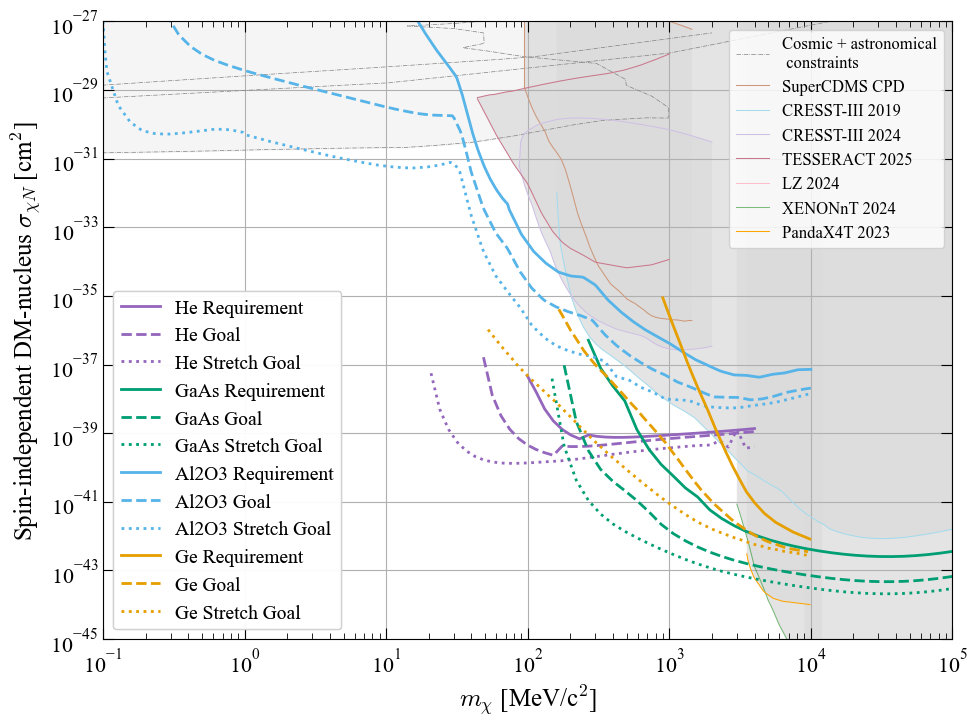

In [22]:
fig, ax, handles_existing = load_and_plot_existing(ER_model='None', lw=0.75, leg=False, cosmic=True, migdal=False, direct=True)
handles_calculated = []
    
m_lim, x_lim = np.loadtxt(GatewayReviewPath+'/herald_requirement.txt', unpack=True)
l, = ax.plot(m_lim*1e3, x_lim, lw=2, color='#9467BD', linestyle='-', label='He Requirement')
handles_calculated.append(l)
m_print = 200e-3
print(f'He requirement: {np.interp(m_print, m_lim, x_lim):.2e} cm^2 at {m_print*1e3:.0f} MeV/c^2')

m_lim, x_lim = np.loadtxt(GatewayReviewPath+'/herald_goal.txt', unpack=True)
l, = ax.plot(m_lim*1e3, x_lim, lw=2, color='#9467BD', linestyle='--', label='He Goal')
handles_calculated.append(l)
m_print = 150e-3
print(f'He goal: {np.interp(m_print, m_lim, x_lim):.2e} cm^2 at {m_print*1e3:.0f} MeV/c^2')

m_lim, x_lim = np.loadtxt(GatewayReviewPath+'/herald_stretch.txt', unpack=True)
l, = ax.plot(m_lim*1e3, x_lim, lw=2, color='#9467BD', linestyle=':', label='He Stretch Goal')
handles_calculated.append(l)
m_print = 75e-3
print(f'He stretch goal: {np.interp(m_print, m_lim, x_lim):.2e} cm^2 at {m_print*1e3:.0f} MeV/c^2')
print('')

m_lim, x_lim = np.loadtxt(GatewayReviewPath+'/gaas_requirement_NR/results_PD_1.33_GaAs_10.0/limit.txt', unpack=True)
l, = ax.plot(m_lim*1e3, x_lim, lw=2, color='#009E73', linestyle='-', label='GaAs Requirement')
handles_calculated.append(l)
m_print = 1
print(f'GaAs requirement: {np.interp(m_print, m_lim, x_lim):.2e} cm^2 at {m_print*1e3:.0f} MeV/c^2')

m_lim, x_lim = np.loadtxt(GatewayReviewPath+'/gaas_goal_NR/results_PD_1.22_GaAs_5.0/limit.txt', unpack=True)
l, = ax.plot(m_lim*1e3, x_lim, lw=2, color='#009E73', linestyle='--', label='GaAs Goal')
handles_calculated.append(l)
m_print = 600e-3
print(f'GaAs goal: {np.interp(m_print, m_lim, x_lim):.2e} cm^2 at {m_print*1e3:.0f} MeV/c^2')

m_lim, x_lim = np.loadtxt(GatewayReviewPath+'/gaas_stretch/results_NR_PD_1.29_GaAs_3.0/limit.txt', unpack=True)
l, = ax.plot(m_lim*1e3, x_lim, lw=2, color='#009E73', linestyle=':', label='GaAs Stretch Goal')
handles_calculated.append(l)
m_print = 400e-3
print(f'GaAs stretch goal: {np.interp(m_print, m_lim, x_lim):.2e} cm^2 at {m_print*1e3:.0f} MeV/c^2')
print('')

m_lim, x_lim = np.loadtxt(GatewayReviewPath+'/sapphire_requirement_NR_massive/combined_results.txt', unpack=True)
l, = ax.plot(m_lim*1e3, x_lim, lw=2, color='#56B4E9', linestyle='-', label='Al2O3 Requirement')
handles_calculated.append(l)
m_print = 50e-3
print(f'Sapphire requirement: {np.interp(m_print, m_lim, x_lim):.2e} cm^2 at {m_print*1e3:.0f} MeV/c^2')

m_lim, x_lim = np.loadtxt(GatewayReviewPath+'/sapphire_goal_NR_massive/combined_results.txt', unpack=True)
l, = ax.plot(m_lim*1e3, x_lim, lw=2, color='#56B4E9', linestyle='--', label='Al2O3 Goal')
handles_calculated.append(l)
m_print = 50e-3
print(f'Sapphire goal: {np.interp(m_print, m_lim, x_lim):.2e} cm^2 at {m_print*1e3:.0f} MeV/c^2')

m_lim, x_lim = np.loadtxt(GatewayReviewPath+'/sapphire_stretch_NR_massive/combined_results.txt', unpack=True)
l, = ax.plot(m_lim*1e3, x_lim, lw=2, color='#56B4E9', linestyle=':', label='Al2O3 Stretch Goal')
handles_calculated.append(l)
m_print = 50e-3
print(f'Sapphire stretch goal: {np.interp(m_print, m_lim, x_lim):.2e} cm^2 at {m_print*1e3:.0f} MeV/c^2')

for i, (vn, ls, label) in enumerate(zip([1, 2, 3], ['-', '--', ':'], ['Requirement', 'Goal', 'Stretch Goal'])):
    m_lim, x_lim = np.loadtxt(get_cache_path('data/2025_preCDR_results/'+f'Ge_v{vn}_with_LEE.txt'), unpack=True)
    l, = ax.plot(m_lim*1e3, x_lim, lw=2, color='#E69F00', linestyle=ls, label=f'Ge {label}')
    handles_calculated.append(l)

ax.set_xlim([1e-1, 1e5])
ax.set_ylim([1e-45, 1e-27])
ax.set_xlabel(r'$m_\chi$ [MeV/c$^2$]', fontsize=18)
ax.set_ylabel(r'Spin-independent DM-nucleus $\sigma_{\chi N}$ [cm$^2$]', fontsize=18)
ax.grid('on')

leg1 = ax.legend(handles=handles_existing, loc='upper right', fontsize=12, frameon=True, ncol=1)
ax.add_artist(leg1)

leg2 = ax.legend(handles=handles_calculated, loc='lower left', fontsize=14, frameon=True, ncol=1)
ax.add_artist(leg2)

fig.tight_layout()
#fig.savefig(GatewayReviewPath+'/TESSERACT_Sensitivities_NR.pdf')
fig.show()

FileNotFoundError: GatewayReview/gaas_requirement_NR/results_PD_1.33_GaAs_10.0/limit.txt not found.

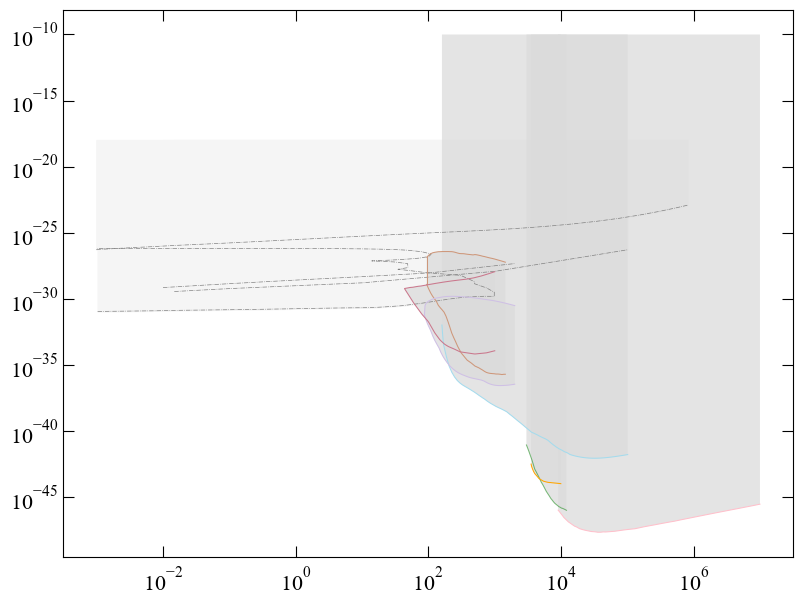

In [23]:
fig, ax, handles_existing = load_and_plot_existing(ER_model='None', lw=0.75, leg=False, cosmic=True, migdal=False, direct=True)
handles_calculated = []
    
m_lim, x_lim = np.loadtxt('GatewayReview/gaas_requirement_NR/results_PD_1.33_GaAs_10.0/limit.txt', unpack=True)
l, = ax.plot(m_lim*1e3, x_lim, lw=2, color='#009E73', linestyle='-', label='GaAs Requirement')
handles_calculated.append(l)

m_lim, x_lim = np.loadtxt('GatewayReview/gaas_goal_NR/results_PD_1.22_GaAs_5.0/limit.txt', unpack=True)
l, = ax.plot(m_lim*1e3, x_lim, lw=2, color='#009E73', linestyle='--', label='GaAs Goal')
handles_calculated.append(l)

m_lim, x_lim = np.loadtxt('GatewayReview/gaas_stretch/results_NR_PD_1.29_GaAs_3.0/limit.txt', unpack=True)
l, = ax.plot(m_lim*1e3, x_lim, lw=2, color='#009E73', linestyle=':', label='GaAs Stretch Goal')
handles_calculated.append(l)

m_lim, x_lim = np.loadtxt('GatewayReview/gaas_requirement_NR_10x_LEE/results_PD_1.33_GaAs_10.0/limit.txt', unpack=True)
l, = ax.plot(m_lim*1e3, x_lim, lw=2, color='#EE1616', linestyle='-', label='GaAs Requirement (10x LEE)')
handles_calculated.append(l)

m_lim, x_lim = np.loadtxt('GatewayReview/gaas_goal_NR_10x_LEE/results_PD_1.22_GaAs_5.0/limit.txt', unpack=True)
l, = ax.plot(m_lim*1e3, x_lim, lw=2, color='#EE1616', linestyle='--', label='GaAs Goal (10x LEE)')
handles_calculated.append(l)

m_lim, x_lim = np.loadtxt('GatewayReview/gaas_stretch_10x_LEE/results_NR_PD_1.29_GaAs_3.0/limit.txt', unpack=True)
l, = ax.plot(m_lim*1e3, x_lim, lw=2, color='#EE1616', linestyle=':', label='GaAs Stretch Goal (10x LEE)')
handles_calculated.append(l)

ax.set_xlim([1e2, 1e5])
ax.set_ylim([1e-44, 1e-35])
ax.set_xlabel(r'$m_\chi$ [MeV/c$^2$]', fontsize=18)
ax.set_ylabel(r'Spin-independent DM-nucleus $\sigma_{\chi N}$ [cm$^2$]', fontsize=18)
ax.grid('on')

leg1 = ax.legend(handles=handles_existing, loc='upper right', fontsize=12, frameon=True, ncol=2)
ax.add_artist(leg1)

leg2 = ax.legend(handles=handles_calculated, loc='center right', fontsize=14, frameon=True, ncol=1)
ax.add_artist(leg2)

fig.tight_layout()
fig.show()

In [24]:
# m_lim, x_lim = np.loadtxt('required_performance_NR_like/projection_300d_3fold/limit.txt', unpack=True)
# l, = ax.plot(m_lim*1e3, x_lim, lw=3, color='#009E73', linestyle='-', label='GaAs requirement2 (3-fold)')
# handles_calculated.append(l)
# j = np.argmin(np.abs(m_lim - 1.0))
# print(f'GaAs requirement2: {m_lim[j]*1e3:.2f} MeV/c^2, {x_lim[j]:.2e} cm^2')

# m_lim, x_lim = np.loadtxt('required_performance_NR_like/projection_300d_2fold/limit.txt', unpack=True)
# l, = ax.plot(m_lim*1e3, x_lim, lw=3, color='orange', linestyle='-', label='GaAs requirement2 (2-fold)')
# handles_calculated.append(l)

# m_lim, x_lim = np.loadtxt('goal_performance_NR_like/projection_300d_3fold/limit.txt', unpack=True)
# l, = ax.plot(m_lim*1e3, x_lim, lw=3, color='#009E73', linestyle='--', label='GaAs Goal (3-fold)')
# handles_calculated.append(l)
# j = np.argmin(np.abs(m_lim - 1.0))
# print(f'GaAs Goal: {m_lim[j]*1e3:.2f} MeV/c^2, {x_lim[j]:.2e} cm^2')

# m_lim, x_lim = np.loadtxt('goal_performance_NR_like/projection_300d_2fold/limit.txt', unpack=True)
# l, = ax.plot(m_lim*1e3, x_lim, lw=3, color='orange', linestyle='--', label='GaAs Goal (2-fold)')
# handles_calculated.append(l)

# m_lim, x_lim = np.loadtxt('stretch_performance_NR_like/projection_300d_3fold/limit.txt', unpack=True)
# l, = ax.plot(m_lim*1e3, x_lim, lw=3, color='#009E73', linestyle=':', label='GaAs Stretch Goal (3-fold)')
# handles_calculated.append(l)
# j = np.argmin(np.abs(m_lim - 1.0))
# print(f'GaAs Stretch Goal: {m_lim[j]*1e3:.2f} MeV/c^2, {x_lim[j]:.2e} cm^2')

# m_lim, x_lim = np.loadtxt('DirectorsReview/sapphire_requirement2_3m/limit.txt', unpack=True)
# l, = ax.plot(m_lim*1e3, x_lim, lw=3, color='#56B4E9', linestyle='-', label='Al2O3 requirement2')
# handles_calculated.append(l)

# m_lim, x_lim = np.loadtxt('DirectorsReview/sapphire_goal_3m/limit.txt', unpack=True)
# l, = ax.plot(m_lim*1e3, x_lim, lw=3, color='#56B4E9', linestyle='--', label='Al2O3 Goal')
# handles_calculated.append(l)

# m_lim, x_lim = np.loadtxt('DirectorsReview/sapphire_stretch_3m/limit.txt', unpack=True)
# l, = ax.plot(m_lim*1e3, x_lim, lw=3, color='#56B4E9', linestyle=':', label='Al2O3 Stretch Goal')
# handles_calculated.append(l)

# m_lim, x_lim = np.loadtxt('updated_sapphire_requirement2/limit.txt', unpack=True)
# handles_calculated.append(l)

# m_lim, x_lim = np.loadtxt('updated_sapphire_requirement2/multiphonon/limit.txt', unpack=True)
# l, = ax.plot(m_lim*1e3, x_lim, lw=3, color='#56B4E9', linestyle='-', label='Al2O3 requirement2')
# handles_calculated.append(l)
# j = np.argmin(np.abs(m_lim - 50e-3))
# print(f'Al2O3 requirement2: {m_lim[j]*1e3:.2f} MeV/c^2, {x_lim[j]:.2e} cm^2')

# m_lim, x_lim = np.loadtxt('updated_sapphire_goal/limit.txt', unpack=True)
# handles_calculated.append(l)

# m_lim, x_lim = np.loadtxt('updated_sapphire_goal/multiphonon/limit.txt', unpack=True)
# l, = ax.plot(m_lim*1e3, x_lim, lw=3, color='#56B4E9', linestyle='--', label='Al2O3 Goal')
# handles_calculated.append(l)
# j = np.argmin(np.abs(m_lim - 10e-3))
# print(f'Al2O3 Goal: {m_lim[j]*1e3:.2f} MeV/c^2, {x_lim[j]:.2e} cm^2')

# m_lim, x_lim = np.loadtxt('sapphire_background_free_goal/limit.txt', unpack=True)
# l, = ax.plot(m_lim*1e3, x_lim, lw=3, color='k', linestyle='-', label='requirement2 Background-Free')
# handles_calculated.append(l)

# m_lim, x_lim = np.loadtxt('sapphire_background_free_requirement2/limit.txt', unpack=True)
# l, = ax.plot(m_lim*1e3, x_lim, lw=3, color='k', linestyle='--', label='requirement2 Background-Free')
# handles_calculated.append(l)

# for i, rate in enumerate([7, 8, 9, 10]):
#     m_lim, x_lim = np.loadtxt(f'sapphire_flat_1e{rate}_DRU_3min_requirement2/limit.txt', unpack=True)
#     l, = ax.plot(m_lim*1e3, x_lim, lw=(2*i+1), color='#56B4E9', linestyle='-', label=f'1e{rate} DRU')
#     handles_calculated.append(l)


# m_lim, x_lim = np.loadtxt('GatewayReview/sapphire_requirement_NR_massive_worse_resolution/combined_results.txt', unpack=True)
# l, = ax.plot(m_lim*1e3, x_lim, lw=2, color='k', linestyle=':', label='Al2O3 Requirement (40 meV res.)')
# handles_calculated.append(l)

# m_lim, x_lim = np.loadtxt('GatewayReview/sapphire_requirement_NR_massive_even_worse_resolution/combined_results.txt', unpack=True)
# l, = ax.plot(m_lim*1e3, x_lim, lw=2, color='r', linestyle=':', label='Al2O3 Requirement (60 meV res.)')
# handles_calculated.append(l)

# m_lim, x_lim = np.loadtxt('sapphire_exploration/test_requirement/limit.txt', unpack=True)
# l, = ax.plot(m_lim*1e3, x_lim, lw=2, color='k', linestyle=':', label='Test Requirement')
# handles_calculated.append(l)

# m_lim, x_lim = np.loadtxt('sapphire_exploration/test_requirement_larger/limit.txt', unpack=True)
# l, = ax.plot(m_lim*1e3, x_lim, lw=2, color='k', linestyle='--', label='Test Requirement (Larger)')
# handles_calculated.append(l)

# m_lim, x_lim = np.loadtxt('sapphire_exploration/test_requirement_worse_resolution/limit.txt', unpack=True)
# l, = ax.plot(m_lim*1e3, x_lim, lw=2, color='r', linestyle=':', label='Test Requirement (Worse resolution)')
# handles_calculated.append(l)

# m_lim, x_lim = np.loadtxt('gaas_exploration/all_background_free/NR_requirement/limit.txt', unpack=True)
# l, = ax.plot(m_lim*1e3, x_lim, lw=2, color='g', label='GaAs Requirement')
# handles_calculated.append(l)

# m_lim, x_lim = np.loadtxt('gaas_exploration/all_background_free/NR_goal/limit.txt', unpack=True)
# l, = ax.plot(m_lim*1e3, x_lim, lw=2, color='g', linestyle='--', label='GaAs Goal')
# handles_calculated.append(l)

# m_lim, x_lim = np.loadtxt('gaas_exploration/all_background_free/NR_stretch/limit.txt', unpack=True)
# l, = ax.plot(m_lim*1e3, x_lim, lw=2, color='g', linestyle=':', label='GaAs Stretch')
# handles_calculated.append(l)


## preCDR results:

FileNotFoundError: sapphire_test_3min_1e11_DRU/limit.txt not found.

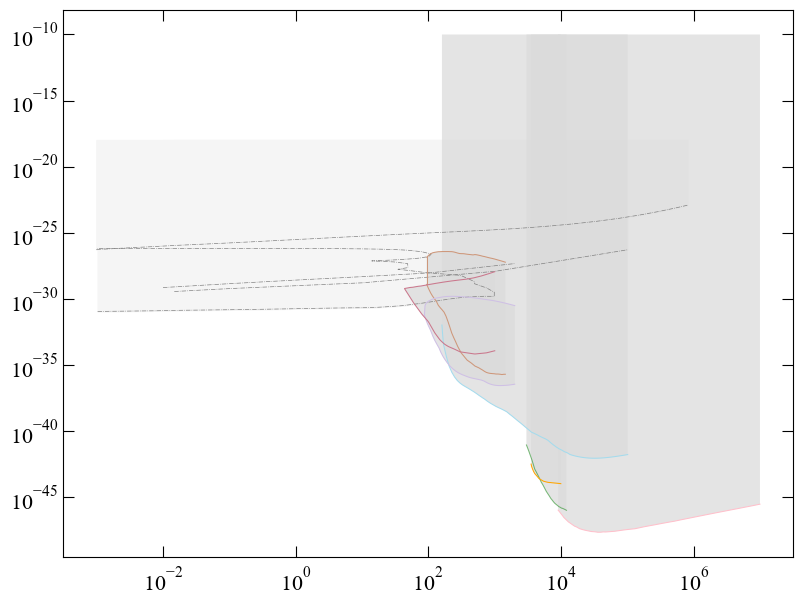

In [25]:
fig, ax, handles_existing = load_and_plot_existing(ER_model='None', lw=0.75, leg=False, cosmic=True, migdal=False, direct=True)
handles_calculated = []

for i, (rate, color) in enumerate(zip([11, 10, 9], ['m', 'g', 'b'])):
    
    m_lim, x_lim = np.loadtxt(f'sapphire_test_3min_1e{rate}_DRU/limit.txt', unpack=True)
    l, = ax.plot(m_lim*1e3, x_lim, lw=3, color=color, linestyle='--', label=f'Sapphire 1e{rate} DRU, 3 minutes')
    handles_calculated.append(l)

m_lim, x_lim = np.loadtxt(f'sapphire_test_3min_1e{8}_DRU/limit.txt', unpack=True)
l, = ax.plot(m_lim*1e3, x_lim, lw=2, color='k', linestyle='-', label=f'Sapphire 1e8 DRU, 3 minutes')
handles_calculated.append(l)

for i, (t, color) in enumerate(zip([30, 300, 3000, 30000], ['red', 'brown', 'orange', 'pink'])):
    m_lim, x_lim = np.loadtxt(f'sapphire_test_{t}min_1e8_DRU/limit.txt', unpack=True)
    l, = ax.plot(m_lim*1e3, x_lim, lw=2, color=color, linestyle=':', label=f'Sapphire 1e8 DRU, {t} minutes')
    handles_calculated.append(l)

# m_lim, x_lim = np.loadtxt(f'sapphire_test_300min_1e{8}_DRU/limit.txt', unpack=True)
# l, = ax.plot(m_lim*1e3, x_lim, lw=2, color='brown', linestyle=':', label=f'Sapphire 1e{8} DRU')
# handles_calculated.append(l)

# m_lim, x_lim = np.loadtxt(f'sapphire_test_3000min_1e{8}_DRU/limit.txt', unpack=True)
# l, = ax.plot(m_lim*1e3, x_lim, lw=2, color='orange', linestyle=':', label=f'Sapphire 1e{8} DRU')
# handles_calculated.append(l)

# m_lim, x_lim = np.loadtxt(f'sapphire_test_30000min_1e{8}_DRU/limit.txt', unpack=True)
# l, = ax.plot(m_lim*1e3, x_lim, lw=2, color='pink', linestyle=':', label=f'Sapphire 1e{8} DRU')
# handles_calculated.append(l)

ax.set_xlim([1.3e1, 3e4])
ax.set_ylim([1e-39, 1e-27])
ax.set_xlabel(r'$m_\chi$ [MeV/c$^2$]', fontsize=18)
ax.set_ylabel(r'Spin-independent DM-nucleus $\sigma_{\chi N}$ [cm$^2$]', fontsize=18)

leg1 = ax.legend(handles=handles_existing, loc='lower left', fontsize=12, frameon=False, ncol=2)
ax.add_artist(leg1)

leg2 = ax.legend(handles=handles_calculated, loc='upper right', fontsize=14, frameon=True, ncol=1)
ax.add_artist(leg2)

fig.tight_layout()
fig.show()

FileNotFoundError: sapphire_background_free_requirement/limit.txt not found.

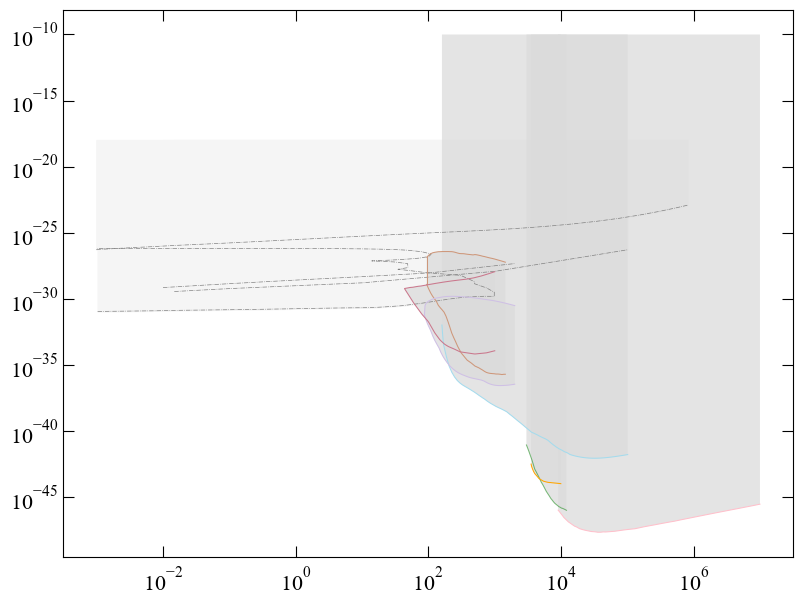

In [26]:
fig, ax, handles_existing = load_and_plot_existing(ER_model='None', lw=0.75, leg=False, cosmic=True, migdal=False, direct=True)
handles_calculated = []

E_th_requirement_keV = 64e-3 * 7 * 1e-3
E_th_goal_keV = 14.7e-3 * 7 * 1e-3
E_max_keV = 1.

m_lim_GeV = np.geomspace(1e-4, 1, 100)
x_lim_requirement = np.zeros_like(m_lim_GeV)
x_lim_goal = np.zeros_like(m_lim_GeV)
sigma_0 = 1e-35

for i, m_GeV in enumerate(m_lim_GeV):
    continue

    drde_fxn = darklim.elf.get_dRdE_lambda_Al2O3_phonon(mX_eV=m_GeV*1e9, mediator='massive', sigman=sigma_0, suppress_darkelf_output=True)

    E_arr = np.geomspace(E_th_requirement_keV, E_max_keV, 250)
    dRdE = np.array([drde_fxn(E) for E in E_arr])
    dRdE_smeared = darklim.limit.gauss_smear(E_arr, dRdE, 64e-6)
    R = np.trapz(dRdE_smeared, E_arr) * (0.009375 * 3.98 * 1e-3) * (3 / 1440)
    x_lim_requirement[i] = sigma_0 / R * 2.3
    
    E_arr = np.geomspace(E_th_goal_keV, E_max_keV, 250)
    dRdE = np.array([drde_fxn(E) for E in E_arr])
    dRdE_smeared = darklim.limit.gauss_smear(E_arr, dRdE, 14.7e-6)
    R = np.trapz(dRdE_smeared, E_arr) * (0.009375 * 3.98 * 1e-3) * (3 / 1440)
    x_lim_goal[i] = sigma_0 / R * 2.3
    
    if i % 10 == 0:
        print(f'Finished mass {i} of {len(m_lim_GeV)}')

# l, = ax.plot(m_lim_GeV*1e3, x_lim_requirement, 'g-', lw=3, label='Requirement Bkgd-Free (actual)')
# handles_calculated.append(l)

# l, = ax.plot(m_lim_GeV*1e3, x_lim_goal, 'g--', lw=3, label='Goal Bkgd-Free (actual)')
# handles_calculated.append(l)

# m_lim, x_lim = np.loadtxt('sapphire_background_free_goal/limit.txt', unpack=True)
# l, = ax.plot(m_lim*1e3, x_lim, lw=3, color='k', linestyle='-', label='Goal Background-Free (DarkLim)')
# handles_calculated.append(l)

# m_lim, x_lim = np.loadtxt('sapphire_LEE_div_1e3_goal/limit.txt', unpack=True)
# l, = ax.plot(m_lim*1e3, x_lim, lw=3, color='m', linestyle='-', label='Goal, with LEE/1000')
# handles_calculated.append(l)

# m_lim, x_lim = np.loadtxt('sapphire_LEE_div_1e2_goal/limit.txt', unpack=True)
# l, = ax.plot(m_lim*1e3, x_lim, lw=3, color='m', linestyle='--', label='Goal, with LEE/100')
# handles_calculated.append(l)

m_lim, x_lim = np.loadtxt('sapphire_background_free_requirement/limit.txt', unpack=True)
l, = ax.plot(m_lim*1e3, x_lim, lw=3, color='k', linestyle='--', label='Requirement Background-Free (DarkLim)')
handles_calculated.append(l)

m_lim, x_lim = np.loadtxt('sapphire_LEE_div_1e3_requirement/limit.txt', unpack=True)
l, = ax.plot(m_lim*1e3, x_lim, lw=3, color='m', linestyle='-', label='Requirement, with LEE/1000')
handles_calculated.append(l)

m_lim, x_lim = np.loadtxt('sapphire_LEE_div_1e2_requirement/limit.txt', unpack=True)
l, = ax.plot(m_lim*1e3, x_lim, lw=3, color='m', linestyle='--', label='Requirement, with LEE/100')
handles_calculated.append(l)

m_lim, x_lim = np.loadtxt('sapphire_LEE_div_1e2_requirement/limit.txt', unpack=True)
l, = ax.plot(m_lim*1e3, x_lim, lw=3, color='b', linestyle=':', label='Requirement, with LEE/10')
handles_calculated.append(l)

ax.set_xlim([1e-1, 3e4])
ax.set_ylim([1e-39, 1e-23])
ax.set_xlabel(r'$m_\chi$ [MeV/c$^2$]', fontsize=18)
ax.set_ylabel(r'Spin-independent DM-nucleus $\sigma_{\chi N}$ [cm$^2$]', fontsize=18)

leg1 = ax.legend(handles=handles_existing, loc='lower left', fontsize=12, frameon=False, ncol=2)
ax.add_artist(leg1)

leg2 = ax.legend(handles=handles_calculated, loc='upper right', fontsize=14, frameon=True, ncol=1)
ax.add_artist(leg2)

fig.tight_layout()
fig.show()

# Can likely ignore everything below this (it was used for projections in March 2025, including for the collaboration meeting)

## Nuclear Recoils

/tmp/ipykernel_2727665/3075123258.py:116: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  lowervernefinal.loc[lowervernefinal.index[-3:], "Y"] = new_values


(10.0, 500.0)

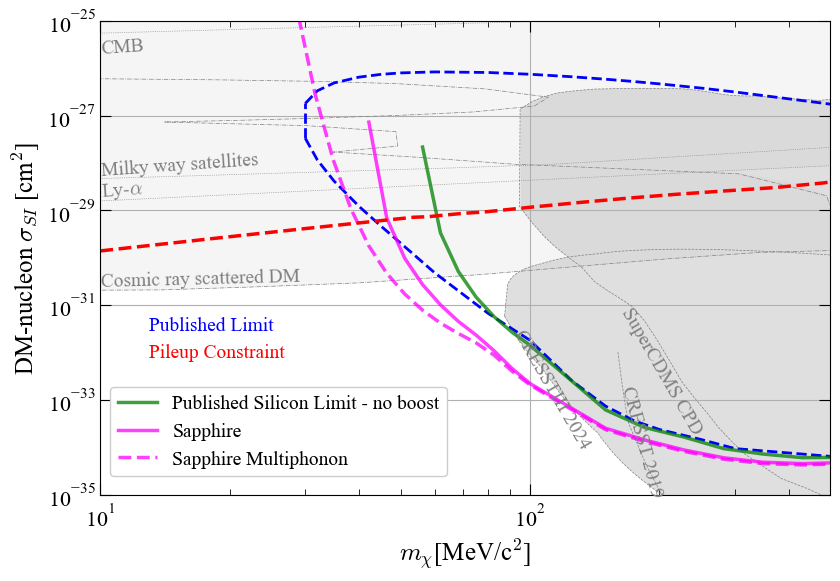

In [25]:
def parse_column(value):
    value = value.decode('utf-8').strip() 
    if value == "[inf]":                  
        return np.inf
    return float(value.strip("[]"))       

m_list = np.geomspace(0.01, 10, num=25)
extra_values = np.array([0.07, 0.068, 0.065, 0.063, 0.06, 0.058])
m_list = np.sort(np.concatenate((m_list, extra_values)))

dmlimits = np.genfromtxt(
    "ExistingLimits/run47_NRDM_limit_Final.txt",
    dtype=float,
    converters={1: parse_column}, 
    delimiter=None                 
)

sigma_diff = dmlimits[:,1]

# NR
fig, ax = plt.subplots(figsize=(10, 6.5))
ax.set_xlabel(r"$m_\chi $[MeV/c$^2$]")
ax.set_ylabel(r"DM-nucleon $\sigma_{SI}$ [cm$^2$]")

y_interp = np.logspace(np.log10(np.min(ML.Data_Cosmic_ray[:,1])),
                             np.log10(np.max(ML.Data_Cosmic_ray[:,1])),
                             200)
ax.fill_betweenx(y_interp,
                 np.ones(200)*1e-2,
                 np.interp(y_interp, ML.Data_Cosmic_ray[:,1],ML.Data_Cosmic_ray[:,0]),
                facecolor='whitesmoke')
ax.fill_between(ML.Data_Milky_way_satellites_2021[:,0],
                np.ones(len(ML.Data_Milky_way_satellites_2021[:,0]))*1e-22,
                ML.Data_Milky_way_satellites_2021[:,1],
                facecolor='whitesmoke')      
ax.fill_between(ML.Data_Ly_alpha_2022[:,0],
                np.ones(len(ML.Data_Ly_alpha_2022[:,0]))*1e-22,
                ML.Data_Ly_alpha_2022[:,1],
                facecolor='whitesmoke') 


#ax.loglog(m_sigma_list[:,0]*1e3,limit_rate[3],'r--',alpha=0.5)


ax.loglog(ML.Data_Cosmic_ray[:,0],ML.Data_Cosmic_ray[:,1],
         linewidth=0.5, color='gray', linestyle='-.')
ax.text(1e1,2.5e-31,"Cosmic ray scattered DM",color='gray',rotation=1.5)

ax.loglog(ML.Data_Milky_way_satellites_2021[:,0],ML.Data_Milky_way_satellites_2021[:,1],
         linewidth=0.5, color='gray', linestyle=':')
ax.text(1e1,ML.Data_Milky_way_satellites_2021[11,1],"Milky way satellites",
        color='gray',rotation=4)
ax.loglog(ML.Data_Ly_alpha_2022[:,0],ML.Data_Ly_alpha_2022[:,1],
         linewidth=0.5, color='gray', linestyle=':')
ax.text(1e1,2e-29,r"Ly-$\alpha$",color='gray',rotation=4)
ax.loglog(ML.Data_CMB[:,0],ML.Data_CMB[:,1],
         linewidth=0.5, color='gray', linestyle=':')
ax.text(1e1,0.2e-25,"CMB",color='gray',rotation=4)

ax.fill_between(ML.m_interp_mb*1e3, ML.limit_interp_Upper_max, ML.limit_interp_Lower_min, 
                facecolor='silver',alpha=0.5)
#print(np.minimum(ML.CRESSTIII_2024[:,2], np.interp(ML.CRESSTIII_2024[:,0], ML.m_interp_mb, ML.limit_interp_Upper_max)))
mass_fill_2 = np.sort(np.append(ML.m_interp_mb*1e3, ML.CRESSTIII_2024[:61,0]*1e3))
mass_fill_2 = mass_fill_2[mass_fill_2<200]
ax.fill_between(mass_fill_2,
                np.minimum(np.interp(mass_fill_2, ML.CRESSTIII_2024[:,0]*1e3, ML.CRESSTIII_2024[:,2]),
                           np.interp(mass_fill_2, ML.m_interp_mb*1e3, ML.limit_interp_Lower_min)),
                np.interp(mass_fill_2, ML.CRESSTIII_2024[:,0]*1e3, ML.CRESSTIII_2024[:,1]),
                facecolor='silver',alpha=0.5)
ax.loglog(np.vstack((ML.cpdlimit_down[::-1],ML.cpdlimit_up))[:,0]*1e3, np.vstack((ML.cpdlimit_down[::-1],ML.cpdlimit_up))[:,1],
         linewidth=0.5, color='gray', linestyle='--')

ax.text(1.6e2,2e-34,"SuperCDMS CPD",color='gray',rotation=-60)
#ax.text(1.8e2,2e-35,"SuperCDMS  ",color='gray',rotation=-72)
#ax.text(4e2,3e-36,"CPD",color='gray',rotation=-40)
#ax.loglog(cpdlimit_up[:,0]*1e3, cpdlimit_up[:,1])
#ax.loglog(CRESSTlimit_2022[:,0]*1e3,CRESSTlimit_2022[:,1],
#         linewidth=0.5, color='gray', linestyle='--')
#ax.text(1.25e2,5e-34,"CRESST 2023",color='gray',rotation=-60)

ax.loglog(ML.CRESSTlimit_2019[:,0]*1e3,ML.CRESSTlimit_2019[:,1],
         linewidth=0.5, color='gray', linestyle='--')
ax.text(1.6e2,1e-35,"CRESST 2019",color='gray',rotation=-75)

ax.loglog(ML.CRESSTIII_2024[11:,0]*1e3,ML.CRESSTIII_2024[11:,1],
         linewidth=0.5, color='gray', linestyle='--')
ax.loglog(ML.CRESSTIII_2024[11:,0]*1e3,ML.CRESSTIII_2024[11:,2],
         linewidth=0.5, color='gray', linestyle='--')
ax.text(90,1e-34,"CRESSTIII 2024",color='gray',rotation=-60)

#ax.text(0.9e2,3e-34,"CRESST",color='gray',rotation=-80)

#ax.loglog(Data_Nova_SuperCDMS[:,0],Data_Nova_SuperCDMS[:,1], color='purple')
#ax.loglog(Data_Nova_QP[:,0],Data_Nova_QP[:,1],color='orange')
'''
m_sigma_list = np.transpose([np.logspace(-5,0,26),1e-30*np.ones(26)])
ax.loglog(m_sigma_list[:,0]*1e3,limit_mp[2],'k-',label=r'Massive, correlated noise')
ax.text(0.5,2e-28,"Correlated noise",rotation=-15)
#ax.loglog(m_sigma_list[:,0]*1e3,limit_mp[3],'k--',label=r'Massless, correlated noise')
#ax.loglog(m_sigma_list[:,0]*1e3,limit_Uncorr[2],'k-',label=r'Massive, uncorrelated noise')
#ax.text(0.5,1.5e-26,"Uncorrelated noise",rotation=-12)
#ax.loglog(m_sigma_list[:,0]*1e3,limit_Uncorr[3],'b--',label=r'Massless, uncorrelated noise')
ax.loglog(m_sigma_list[:,0]*1e3,limit_rate[2],'r-',alpha=0.5)
ax.text(0.1,1e-28,r'$R_{total}$=1kHz',color='red',alpha=0.5)
'''
#ax.loglog(m_sigma_list[:,0]*1e3,limit_rate[3],'r--',alpha=0.5)



verne_final = pd.read_csv('ExistingLimits/verne_result_final.cvs')
verne_final.columns = ["X", "Y"]
lowervernefinal = verne_final.iloc[:len(verne_final)//2]
uppervernefinal = verne_final.iloc[len(verne_final)//2:]
new_values = [6.564e-35, 8.029e-35, 1.154e-34]  

lowervernefinal.loc[lowervernefinal.index[-3:], "Y"] = new_values

new_row = pd.DataFrame({"X": [0.03], "Y": [3.30520e-28]})
lowervernefinal = pd.concat([new_row, lowervernefinal], ignore_index=True)


verne_unblind = pd.read_csv('ExistingLimits/verne_result_noblind.cvs')
verne_unblind.columns = ["X", "Y"]
lowerverneunblind = verne_unblind.iloc[:len(verne_unblind)//2]
upperverneunblind = verne_unblind.iloc[len(verne_unblind)//2:]
new_values = [5.02397519e-35,6.09179215e-35, 8.57781172e-35]  

verne_unblind.iloc[-3:, 1] = new_values

ax.loglog(lowervernefinal["X"]*1e3, lowervernefinal["Y"],'b--')
#ax.loglog(verne_unblind["X"]*1e3, verne_unblind["Y"],'k--',label='Unrestricted')

ax.loglog(uppervernefinal["X"]*1e3, uppervernefinal["Y"],'b--')


#m_list = lowervernefinal["X"]

#m_list = np.array(m_list)
#lowervernefinal = np.array(lowervernefinal["Y"])

# Ensure sorting is done correctly
#sorted_indices = np.argsort(m_list)
#m_list = m_list[sorted_indices]
#lowervernefinal = lowervernefinal[sorted_indices]


#Noise Limit
NoiseLimit= np.array(np.loadtxt("ExistingLimits/NoiseLimitR47.txt"))

#ax.plot(NoiseLimit[:,0],NoiseLimit[:,1],
#         linewidth=2, color='Black', linestyle='-',label='Noise Limit')


m_list_for_plot = m_list[m_list>=0.045]
sigma_diff_for_plot = sigma_diff[m_list>=0.045] #sigma_diff[m_list>=0.041]
m_list_for_plot=np.insert(m_list_for_plot, 0, 0.045)
sigma_diff_for_plot = np.insert(sigma_diff_for_plot, 0, interpolate.interp1d(m_list,sigma_diff)(0.045))
m_list_for_plot=np.insert(m_list_for_plot, 0, 0.045)

# R_5kHz_60MeV = interpolate.interp1d(m_list, 1e-41*5e3/(0.23e-3*np.array(R_m)/3600/24))(0.045)
# sigma_diff_for_plot = np.insert(sigma_diff_for_plot, 0, R_5kHz_60MeV)
#ax.loglog(m_list_for_plot*1e3,sigma_diff_for_plot,'b',label='TESSERACT\n'+r'1cm$^2$ Device')
#ax.loglog(m_list[:]*1e3,sigma_diff[:],'k--',alpha=0.7,label='No Overburden Lower')



#ax.loglog(lowerverneunblind["X"]*1e3, lowerverneunblind["Y"],'y--')

#ax.loglog(verne_unblind["X"]*1e3, verne_unblind["Y"],'y--')
#ax.loglog(TriggerLimits[:,0]*1e3,TriggerLimits[:,1],'b--',label=r'No boost')
#ax.text(30,10e-34,"",color='b',rotation=-60)
#ax.loglog(np.array(m_list_Upper_8hour_3m[8:])*1e3,limit_Upper_8hour_3m[8:],'b')
m_list_dash = m_list[m_list<=0.045]
sigma_diff_dash= sigma_diff[m_list<=0.045]
#ax.loglog(np.append(np.array(m_list_Upper_8hour_3m[::-1])*1e3, m_list_dash[5:]*1e3),
#          np.append(limit_Upper_8hour_3m[::-1], sigma_diff_dash[5:]),
#          'g--',label='Overburden Constraint',alpha=0.7)

#ax.loglog(np.array(m_list_Upper_8hour_3m[0:8])*1e3,limit_Upper_8hour_3m[0:8],'b--')
#upper limit - 5kHz

# R_5kHz_plot = np.insert(1e-41*5.5e3/(0.23e-3*np.array(R_m)[m_list>=0.045]/3600/24), 0,  R_5kHz_60MeV)
# m_5kHz_plot = np.insert(m_list[m_list>=0.045],0,0.045)
# #ax.loglog(m_5kHz_plot*1e3, R_5kHz_plot,'r--')
# ax.loglog(m_list*1e3, 1e-41*5.5e3/(0.23e-3*np.array(R_m)/3600/24),color='r',linestyle=':',alpha=0.7)
# print(1e-41*5.5e3/(0.23e-3*np.array(R_m)/3600/24))
#ax.text(45,1e-29,r'$R_{Total}$ = 5.5 kHz',color='r',rotation=7)
#ax.text(45,1e-29,'Pileup Constraint',color='r',rotation=7,size = 8)
#ax.text(90,2e-27,'Overburden Constraint',color='g',rotation=-7)
ax.text(1.3e1, 3e-32, 'Published Limit',color='b')
fillmass = lowervernefinal["X"] 
mask = fillmass > 0.04
fillmass = fillmass[mask] 
fillsig = lowervernefinal["Y"][mask]

corrlimx = [0.06*1e3,0.06*1e3]
corrlimy = [5.05e-31, 7e-30]
#ax.loglog(corrlimx, corrlimy, color = 'purple',linestyle = '-',label = "Mass Cutoff")

# ax.fill_between(fillmass*1e3,
#                 fillsig,
#                  np.interp(fillmass, m_5kHz_plot,R_5kHz_plot),
#                 facecolor='blue',alpha=0.2,label='TESSERACT-Si\n' 'Exclusion')

x_values = [0.03*1e3, 0.03*1e3]  # Same x for both points (vertical line)
y_values = [3.30520e-28, 1.79855e-27]

# Plot the line
ax.loglog(x_values, y_values, 'b--')



# Add Kurinsky curve
das_kurinsky = np.genfromtxt(
    "ExistingLimits/Das_Kurinsky_2024.txt",
    dtype=float,
    converters={1: parse_column}, 
    delimiter=None                 
)

#ax.loglog(das_kurinsky[:,0]*1e3, das_kurinsky[:,1], color='gray', linewidth=1.)
#ax.text(2e2, 0.3e-27, "Noise Power",color='gray',rotation=-6)



def parse_column(value):
    value = value.decode('utf-8').strip() 
    if value == "[inf]":                  
        return np.inf
    return float(value.strip("[]"))  

oldlims = np.genfromtxt(
    "ExistingLimits/run47_NRDM_limit_noboost_nodrde.txt",
    dtype=float,
    converters={1: parse_column}, 
    delimiter=None                 
)

r47lims_sapphire = np.genfromtxt(
    "ExistingLimits/run47_sapphire_NRDM_limit_noboost_nodrde.txt",
    dtype=float,
    converters={1: parse_column}, 
    delimiter=None                 
)

r47lims_sapphire_phonon = np.genfromtxt(
    "ExistingLimits/run47_sapphire_phonon_limit_noboost_nodrde.txt",
    dtype=float,
    converters={1: parse_column}, 
    delimiter=None                 
)

r57lims = np.genfromtxt(
    "ExistingLimits/run57_NRDM_limit_noboost_nodrde.txt",
    dtype=float,
    converters={1: parse_column}, 
    delimiter=None                 
)

r57lims_sapphire = np.genfromtxt(
    "ExistingLimits/run57_sapphire_NRDM_limit_noboost_nodrde.txt",
    dtype=float,
    converters={1: parse_column}, 
    delimiter=None                 
)

r57lims_sapphire_phonon = np.genfromtxt(
    "ExistingLimits/run57_sapphire_phonon_limit_noboost_nodrde.txt",
    dtype=float,
    converters={1: parse_column}, 
    delimiter=None                 
)

ax.loglog(oldlims[:,0]*1e3, oldlims[:,1], color='g',label=r"Published Silicon Limit - no boost",lw=2.5,alpha=0.75)
ax.loglog(r47lims_sapphire[:,0]*1e3, r47lims_sapphire[:,1], color='magenta',label=r"Sapphire",lw=2.5,alpha=0.75)
ax.loglog(r47lims_sapphire_phonon[:,0]*1e3, r47lims_sapphire_phonon[:,1], '--', color='magenta',label=r"Sapphire Multiphonon",lw=2.5,alpha=0.75)
#ax.loglog(r57lims[:,0]*1e3, r57lims[:,1], color='m',label=r"Run 57 Limits - No boost or dRdE",lw=2.5,alpha=0.75)
#ax.loglog(r57lims_sapphire[:,0]*1e3, r57lims_sapphire[:,1], color='brown',label=r"Run 57 Sapphire",lw=2.5,alpha=0.75)
#ax.loglog(r57lims_sapphire_phonon[:,0]*1e3, r57lims_sapphire_phonon[:,1], '--', color='brown',label=r"Run 57 Sapphire Multiphonon",lw=2.5,alpha=0.75)

r47_pileup = np.genfromtxt(
    "ExistingLimits/TESSERACT_2025_Pileup.txt",
    dtype=float,
    converters={1: parse_column}, 
    delimiter=None                 
)
ax.loglog(r47_pileup[:,0]*1e3, r47_pileup[:,1], '--', color='r', lw=2.5)
ax.text(1.3e1, 8e-33,'Pileup Constraint', color='r')


for i, (baseline_meV, color) in \
    enumerate(zip([370, 200, 100, 80, 50, 30, 20],
        ['#d62728', '#ff7f0e', '#bcbd22', '#2ca02c', '#17becf', '#1f77b4','#e377c2', '#9467bd', '#8c564b'])):
       
    # m_limit, x_limit = np.loadtxt(f'projections_2025/sapphire_r57_bkgd_1sec_{baseline_meV}meV_NR/limit.txt').transpose()
    # ax.plot(m_limit*1e3, x_limit, '-', color=color, lw=2.5, label=f'E_thresh = {5*baseline_meV} meV')# + (' (Al2O3)' if i == 0 else ''))

    # m_limit, x_limit = np.loadtxt(f'projections_2025/sapphire_r57_bkgd_1sec_{baseline_meV}meV_phonon_massive/limit.txt').transpose()
    # ax.plot(m_limit*1e3, x_limit, '--', color=color, lw=2.5)

    # m_limit, x_limit = np.loadtxt(f'projections_2025/sapphire_r57_bkgd_10sec_{baseline_meV}meV_NR/limit.txt').transpose()
    # ax.plot(m_limit*1e3, x_limit, '-', color=color, lw=2.5)

    # m_limit, x_limit = np.loadtxt(f'projections/sapphire_1sec_{baseline_meV}meV_NR/limit.txt').transpose()
    # ax.plot(m_limit*1e3, x_limit, '-', color=color, lw=2.5, label=f'E_threshold = {baseline_meV*5} meV')

    # m_limit, x_limit = np.loadtxt(f'projections/sapphire_1sec_{baseline_meV}meV_phonon_massive/limit.txt').transpose()
    # ax.plot(m_limit*1e3, x_limit, '--', color=color, lw=2.5)

    pass

ax.grid()
ax.legend(loc='lower left', frameon=True, bbox_to_anchor=(0, 0.02), framealpha=1)
ax.set_ylim(1e-35,1e-25)
ax.set_xlim(1e1,5e2)
#fig.savefig('/home/michael/DarkLim/examples/Run47Limit_NR_paper.pdf',bbox_inches="tight")

#print(np.transpose([m_list_for_plot*1e3,sigma_diff_for_plot]))

NameError: name 'plotexcludedNR' is not defined

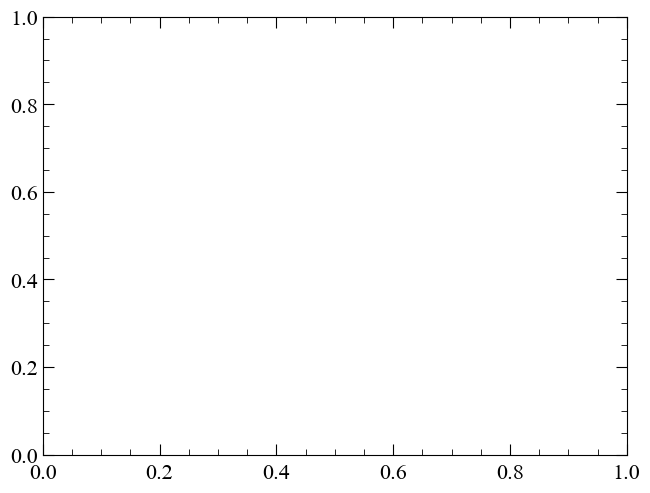

In [ ]:
colors = ['blue','green','darkorange']

lss = ['-','-','-']
    
fig, ax = plt.subplots(1, 1, figsize=(8,6))

plotexcludedNR(ax, details=True)
#leg_params = {'loc':'upper right',
#              'frameon':True,
#              'handlelength':1.5,
#              'fontsize':9,
#              'ncol':3 }
leg_params = {'loc':'upper right',
              'frameon':False,
              'handlelength':1.5,
              'fontsize':11,
              'ncol':1 }
load_and_plot_existing(ax,leg=True,lw=1.5,leg_params=leg_params, ER_model='None')

leg_hands = []

m_limit, x_limit = np.loadtxt('Run47_Results/Run47_limit_NR/limit.txt', unpack=True)
lh, = plt.plot(m_limit*1e3, x_limit, color='k', ls='--', lw=2.5, label='Silicon NR')
leg_hands.append(lh)

m_limit, x_limit = np.loadtxt('Run47_Results/Run47_limit_phonon_massive/limit.txt', unpack=True)
lh, = plt.plot(m_limit*1e3, x_limit, color='c', ls='--', lw=2.5, label='Si multiphonon (massive mediator)')
leg_hands.append(lh)

m_limit, x_limit = np.loadtxt('Run47_Results/Run47_limit_phonon_massless/limit.txt', unpack=True)
lh, = plt.plot(m_limit*1e3, x_limit, color='b', ls='--', lw=2.5, label='Si multiphonon (massless mediator)')
leg_hands.append(lh)

#ax.text(1e2, 5e-36, r'F$_{DM}$ = 1', fontsize=18)

ax.set_yscale('log')
ax.set_xscale('log')

ax.set_ylim(1e-39, 2e-20)
ax.set_xlim(1e1, 1e4)
ax.set_xlabel("Dark Matter Mass [MeV/c$^2$]", fontsize=14)
ax.set_ylabel("DM-Nucleon Cross Section [cm$^2$]", fontsize=14)

#ax.grid(lw=0.3,ls='--',color='grey')
#ax.grid(which="minor", linestyle='dotted')
ax.tick_params(which="both", direction="in", right=True, top=True)

ax.legend(handles=leg_hands, frameon=False, ncol=1, loc='lower left', fontsize=13)

#plt.savefig('./pretty_plots/herald_limits_{:0.1f}g_{:0.0f}d.png'.format(mass_det*1e3,times[i]),facecolor='white',bbox_inches='tight')

## Run 47 Multiphonon

/tmp/ipykernel_979286/3201322330.py:14: RuntimeWarning: All-NaN axis encountered
  result = np.nanmin([result, yinterp], axis=0)
/tmp/ipykernel_979286/3201322330.py:87: MatplotlibDeprecationWarning: An artist whose label starts with an underscore was passed to legend(); such artists will no longer be ignored in the future.  To suppress this warning, explicitly filter out such artists, e.g. with `[art for art in artists if not art.get_label().startswith('_')]`.
  leg1 = ax.legend(handles=[l1, l2, l3, l4, l5, l6], **leg_params)


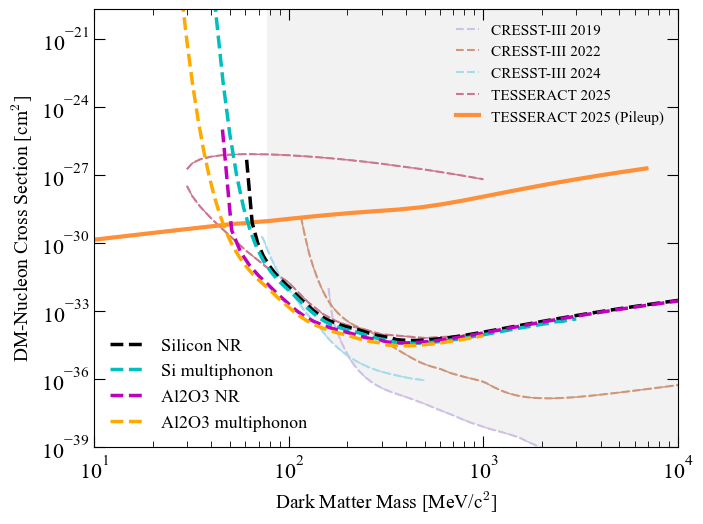

In [ ]:
colors = ['blue','green','darkorange']

lss = ['-','-','-']
    
fig, ax = plt.subplots(1, 1, figsize=(8,6))

plotexcludedNR(ax, details=True)
#leg_params = {'loc':'upper right',
#              'frameon':True,
#              'handlelength':1.5,
#              'fontsize':9,
#              'ncol':3 }
leg_params = {'loc':'upper right',
              'frameon':False,
              'handlelength':1.5,
              'fontsize':11,
              'ncol':1 }
load_and_plot_existing(ax,leg=True,lw=1.5,leg_params=leg_params, ER_model='None')

leg_hands = []

m_limit, x_limit = np.loadtxt('Run47_Results/Run47_limit_NR/limit.txt', unpack=True)
lh, = plt.plot(m_limit*1e3, x_limit, color='k', ls='--', lw=2.5, label='Silicon NR')
leg_hands.append(lh)

m_limit, x_limit = np.loadtxt('Run47_Results/Run47_limit_phonon_massive/limit.txt', unpack=True)
lh, = plt.plot(m_limit*1e3, x_limit, color='c', ls='--', lw=2.5, label='Si multiphonon')
leg_hands.append(lh)

m_limit, x_limit = np.loadtxt('Run47_Results/Run47_sapphire_limit_NR/limit.txt', unpack=True)
lh, = plt.plot(m_limit*1e3, x_limit, color='m', ls='--', lw=2.5, label='Al2O3 NR')
leg_hands.append(lh)

m_limit, x_limit = np.loadtxt('Run47_Results/Run47_sapphire_limit_phonon_massive/limit.txt', unpack=True)
lh, = plt.plot(m_limit*1e3, x_limit, color='#ffaa00', ls='--', lw=2.5, label='Al2O3 multiphonon')
leg_hands.append(lh)

#ax.text(1e2, 5e-36, r'F$_{DM}$ = 1', fontsize=18)

ax.set_yscale('log')
ax.set_xscale('log')

ax.set_ylim(1e-39, 2e-20)
ax.set_xlim(1e1, 1e4)
ax.set_xlabel("Dark Matter Mass [MeV/c$^2$]", fontsize=14)
ax.set_ylabel("DM-Nucleon Cross Section [cm$^2$]", fontsize=14)

#ax.grid(lw=0.3,ls='--',color='grey')
#ax.grid(which="minor", linestyle='dotted')
ax.tick_params(which="both", direction="in", right=True, top=True)

ax.legend(handles=leg_hands, frameon=False, ncol=1, loc='lower left', fontsize=13)

#plt.savefig('./pretty_plots/herald_limits_{:0.1f}g_{:0.0f}d.png'.format(mass_det*1e3,times[i]),facecolor='white',bbox_inches='tight')

## Run 47 ER

/tmp/ipykernel_979286/3201322330.py:14: RuntimeWarning: All-NaN axis encountered
  result = np.nanmin([result, yinterp], axis=0)


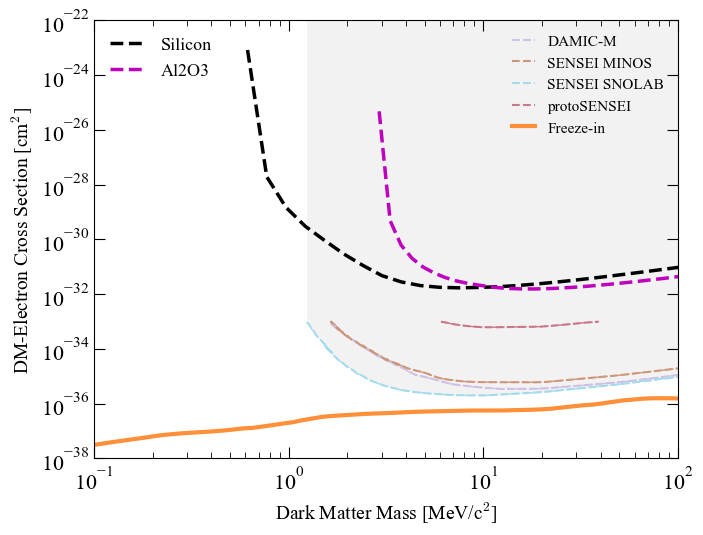

In [ ]:
colors = ['blue','green','darkorange']

lss = ['-','-','-']
    
fig, ax = plt.subplots(1, 1, figsize=(8,6))

plotexcludedmassless(ax, details=True)
#leg_params = {'loc':'upper right',
#              'frameon':True,
#              'handlelength':1.5,
#              'fontsize':9,
#              'ncol':3 }
leg_params = {'loc':'upper right',
              'frameon':False,
              'handlelength':1.5,
              'fontsize':11,
              'ncol':1 }
load_and_plot_existing(ax,leg=True,lw=1.5,leg_params=leg_params, ER_model='massless')

leg_hands = []

m_limit, x_limit = np.loadtxt('Run47_Results/Run47_limit_electron_massless/limit.txt', unpack=True)
lh, = plt.plot(m_limit*1e3, x_limit, color='k', ls='--', lw=2.5, label='Silicon')
leg_hands.append(lh)

m_limit, x_limit = np.loadtxt('Run47_Results/Run47_sapphire_limit_electron_massless/limit.txt', unpack=True)
lh, = plt.plot(m_limit*1e3, x_limit, color='m', ls='--', lw=2.5, label='Al2O3')
leg_hands.append(lh)

#ax.text(1e2, 5e-36, r'F$_{DM}$ = 1', fontsize=18)

ax.set_yscale('log')
ax.set_xscale('log')

ax.set_ylim(1e-38, 1e-22)
ax.set_xlim(1e-1, 1e2)
ax.set_xlabel("Dark Matter Mass [MeV/c$^2$]", fontsize=14)
ax.set_ylabel("DM-Electron Cross Section [cm$^2$]", fontsize=14)

#ax.grid(lw=0.3,ls='--',color='grey')
#ax.grid(which="minor", linestyle='dotted')
ax.tick_params(which="both", direction="in", right=True, top=True)

ax.legend(handles=leg_hands, frameon=False, ncol=1, loc='upper left', fontsize=13)

#plt.savefig('./pretty_plots/herald_limits_{:0.1f}g_{:0.0f}d.png'.format(mass_det*1e3,times[i]),facecolor='white',bbox_inches='tight')

/tmp/ipykernel_979286/3201322330.py:14: RuntimeWarning: All-NaN axis encountered
  result = np.nanmin([result, yinterp], axis=0)


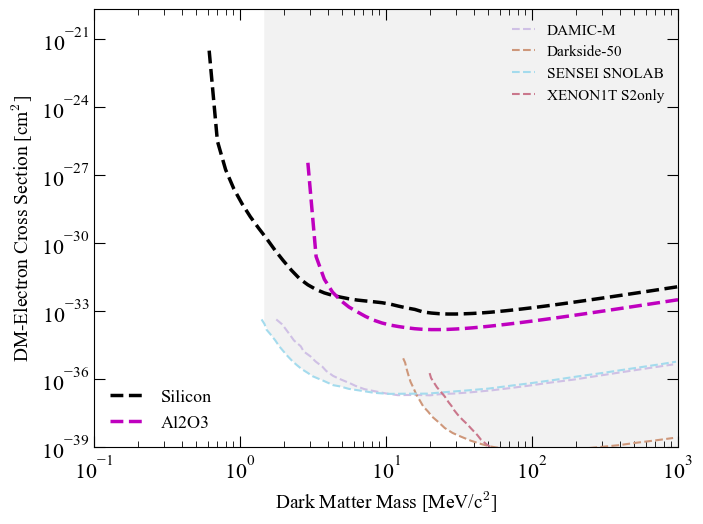

In [ ]:
colors = ['blue','green','darkorange']

lss = ['-','-','-']
    
fig, ax = plt.subplots(1, 1, figsize=(8,6))

plotexcludedmassive(ax, details=False)
#leg_params = {'loc':'upper right',
#              'frameon':True,
#              'handlelength':1.5,
#              'fontsize':9,
#              'ncol':3 }
leg_params = {'loc':'upper right',
              'frameon':False,
              'handlelength':1.5,
              'fontsize':11,
              'ncol':1 }
load_and_plot_existing(ax,leg=True,lw=1.5,leg_params=leg_params, ER_model='massive')

leg_hands = []

m_limit, x_limit = np.loadtxt('Run47_Results/Run47_limit_electron_massive/limit.txt', unpack=True)
lh, = plt.plot(m_limit*1e3, x_limit, color='k', ls='--', lw=2.5, label='Silicon')
leg_hands.append(lh)

m_limit, x_limit = np.loadtxt('Run47_Results/Run47_sapphire_limit_electron_massive/limit.txt', unpack=True)
lh, = plt.plot(m_limit*1e3, x_limit, color='m', ls='--', lw=2.5, label='Al2O3')
leg_hands.append(lh)

#ax.text(1e2, 5e-36, r'F$_{DM}$ = 1', fontsize=18)

ax.set_yscale('log')
ax.set_xscale('log')

ax.set_ylim(1e-39, 2e-20)
ax.set_xlim(1e-1, 1e3)
ax.set_xlabel("Dark Matter Mass [MeV/c$^2$]", fontsize=14)
ax.set_ylabel("DM-Electron Cross Section [cm$^2$]", fontsize=14)

#ax.grid(lw=0.3,ls='--',color='grey')
#ax.grid(which="minor", linestyle='dotted')
ax.tick_params(which="both", direction="in", right=True, top=True)

ax.legend(handles=leg_hands, frameon=False, ncol=1, loc='lower left', fontsize=13)

#plt.savefig('./pretty_plots/herald_limits_{:0.1f}g_{:0.0f}d.png'.format(mass_det*1e3,times[i]),facecolor='white',bbox_inches='tight')

## Projections: Sapphire, Exponential LEE

/tmp/ipykernel_979286/3201322330.py:14: RuntimeWarning: All-NaN axis encountered
  result = np.nanmin([result, yinterp], axis=0)
/tmp/ipykernel_979286/3201322330.py:87: MatplotlibDeprecationWarning: An artist whose label starts with an underscore was passed to legend(); such artists will no longer be ignored in the future.  To suppress this warning, explicitly filter out such artists, e.g. with `[art for art in artists if not art.get_label().startswith('_')]`.
  leg1 = ax.legend(handles=[l1, l2, l3, l4, l5, l6], **leg_params)


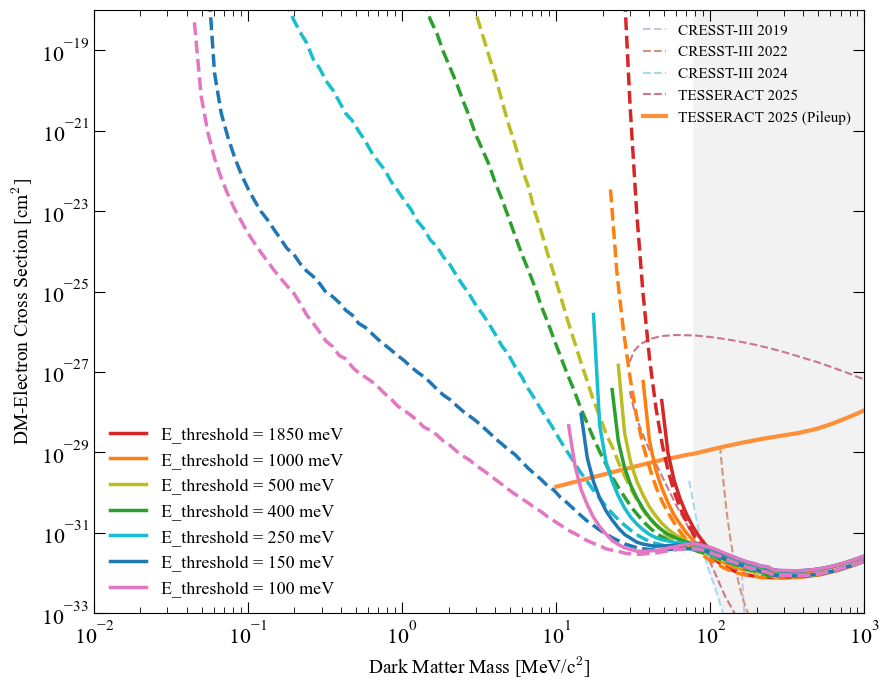

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(9,7))

plotexcludedNR(ax, details=False)
leg_params = {'loc':'upper right',
              'frameon':False,
              'handlelength':1.5,
              'fontsize':11,
              'ncol':1 }
load_and_plot_existing(ax,leg=True,lw=1.5,leg_params=leg_params, ER_model='None')

leg_hands = []

for (baseline_meV, color) in \
    zip([370, 200, 100, 80, 50, 30, 20],
        ['#d62728', '#ff7f0e', '#bcbd22', '#2ca02c', '#17becf', '#1f77b4','#e377c2', '#9467bd', '#8c564b']):
        
    m_limit, x_limit = np.loadtxt(f'projections/sapphire_1sec_{baseline_meV}meV_NR/limit.txt').transpose()
    lh, = ax.plot(m_limit*1e3, x_limit, '-', color=color, lw=2.5, label=f'E_threshold = {baseline_meV*5} meV')
    leg_hands.append(lh)

    m_limit, x_limit = np.loadtxt(f'projections/sapphire_1sec_{baseline_meV}meV_phonon_massive/limit.txt').transpose()
    ax.plot(m_limit*1e3, x_limit, '--', color=color, lw=2.5)

ax.set_yscale('log')
ax.set_xscale('log')

ax.set_ylim(1e-33, 1e-18)
ax.set_xlim(1e-2, 1e3)
ax.set_xlabel("Dark Matter Mass [MeV/c$^2$]", fontsize=14)
ax.set_ylabel("DM-Electron Cross Section [cm$^2$]", fontsize=14)

#ax.grid(lw=0.3,ls='--',color='grey')
#ax.grid(which="minor", linestyle='dotted')
ax.tick_params(which="both", direction="in", right=True, top=True)

ax.legend(handles=leg_hands, frameon=False, ncol=1, loc='lower left', fontsize=13)

fig.tight_layout()
fig.show()


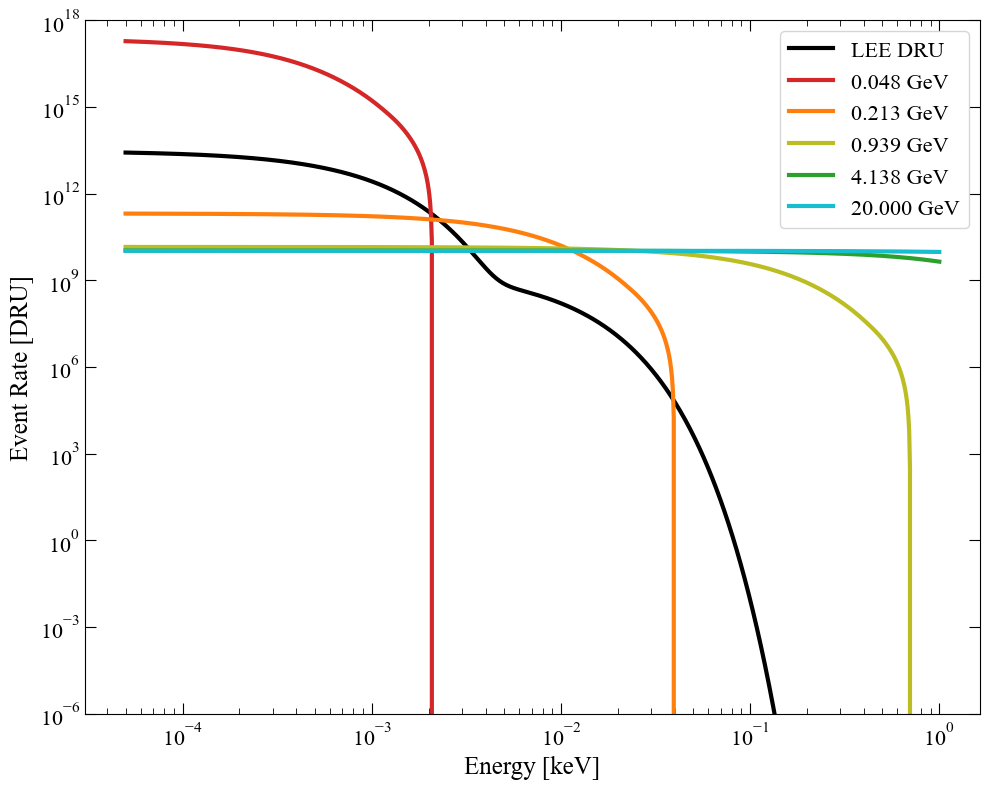

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(10, 8))

# Plot LEE spectrum
E_keV = np.geomspace(50e-6, 1, 1000)
dRdE_LEE_DRU = 2.972e13 * np.exp(-1 * E_keV / 4.137e-4) + 2.205e9 * np.exp(-1 * E_keV / 3.808e-3)

ax.plot(E_keV, dRdE_LEE_DRU, 'k-', lw=3, label='LEE DRU')
m_limit, x_limit = np.loadtxt(f'projections/sapphire_1sec_370meV_NR/limit.txt').transpose()

cut = ~np.isinf(m_limit) * ~np.isinf(x_limit)
m_limit = m_limit[cut]
x_limit = x_limit[cut]

idxs = np.linspace(0, len(m_limit)-1, 5, dtype=int)
for i, (m, x, color) in enumerate(zip(m_limit[idxs],
                                      x_limit[idxs],
                                      ['#d62728', '#ff7f0e', '#bcbd22', '#2ca02c', '#17becf', '#1f77b4','#e377c2', '#9467bd', '#8c564b'])):
    ax.plot(E_keV, darklim.limit.drde(E_keV, m, x, 'Al2O3'), '-', color=color, lw=3, label=f'{m:.3f} GeV')

ax.set_xlabel('Energy [keV]')
ax.set_ylabel('Event Rate [DRU]')
ax.set_yscale('log')
ax.set_ylim([1e-6, 1e18])
ax.set_xscale('log')
ax.legend(loc='best', fontsize=16)
fig.tight_layout()
fig.show()


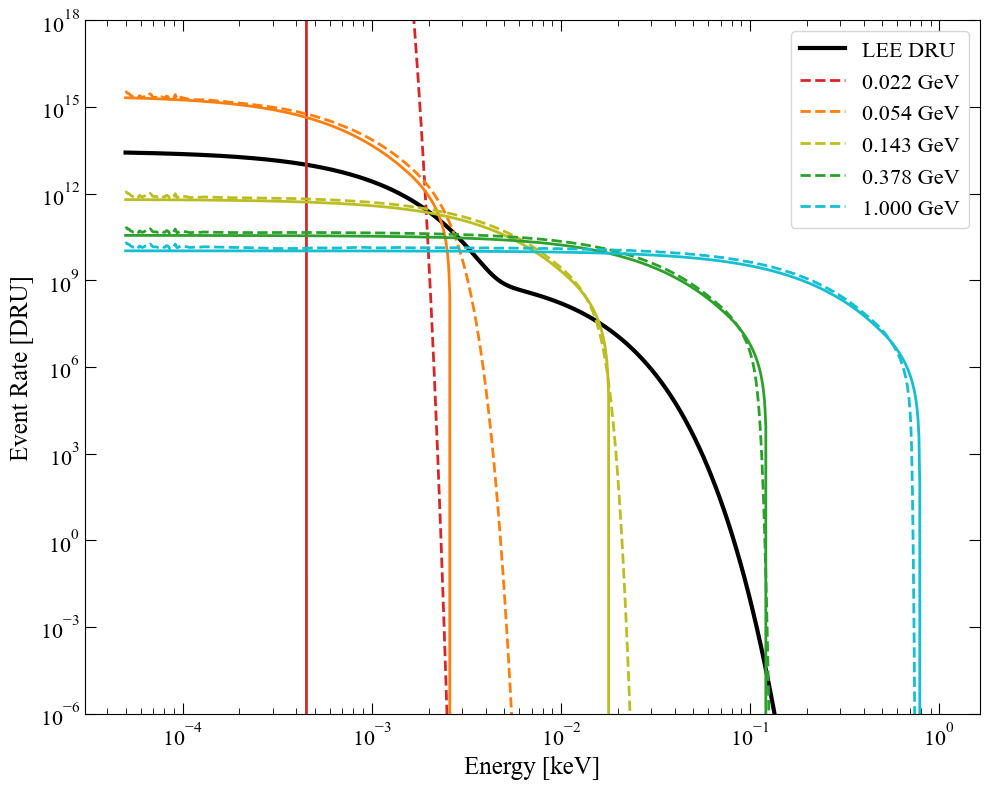

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(10, 8))

# Plot LEE spectrum
E_keV = np.geomspace(50e-6, 1, 1000)
dRdE_LEE_DRU = 2.972e13 * np.exp(-1 * E_keV / 4.137e-4) + 2.205e9 * np.exp(-1 * E_keV / 3.808e-3)

ax.plot(E_keV, dRdE_LEE_DRU, 'k-', lw=3, label='LEE DRU')
m_limit, x_limit = np.loadtxt(f'projections/sapphire_1sec_370meV_phonon_massive/limit.txt').transpose()

cut = ~np.isinf(m_limit) * ~np.isinf(x_limit)
m_limit = m_limit[cut]
x_limit = x_limit[cut]

idxs = np.linspace(0, len(m_limit)-1, 5, dtype=int)
for i, (m, x, color) in enumerate(zip(m_limit[idxs],
                                      x_limit[idxs],
                                      ['#d62728', '#ff7f0e', '#bcbd22', '#2ca02c', '#17becf', '#1f77b4','#e377c2', '#9467bd', '#8c564b'])):
    
    dRdE = darklim.elf.get_dRdE_lambda_Al2O3_phonon(mX_eV=m*1e9, sigman=x, mediator='massive',
                                                    dark_photon=False,
                                                    suppress_darkelf_output=True, gain=1.0)
    dRdE = [dRdE(E) for E in E_keV]
    
    ax.plot(E_keV, darklim.limit.drde(E_keV, m, x, 'Al2O3'), '-', color=color, lw=2)
    ax.plot(E_keV, dRdE, '--', color=color, lw=2, label=f'{m:.3f} GeV')

ax.set_xlabel('Energy [keV]')
ax.set_ylabel('Event Rate [DRU]')
ax.set_yscale('log')
ax.set_ylim([1e-6, 1e18])
ax.set_xscale('log')
ax.legend(loc='best', fontsize=16)
fig.tight_layout()
fig.show()


## Projections: Sapphire, Power-Law LEE

/tmp/ipykernel_979286/3201322330.py:14: RuntimeWarning: All-NaN axis encountered
  result = np.nanmin([result, yinterp], axis=0)
/tmp/ipykernel_979286/3201322330.py:87: MatplotlibDeprecationWarning: An artist whose label starts with an underscore was passed to legend(); such artists will no longer be ignored in the future.  To suppress this warning, explicitly filter out such artists, e.g. with `[art for art in artists if not art.get_label().startswith('_')]`.
  leg1 = ax.legend(handles=[l1, l2, l3, l4, l5, l6], **leg_params)


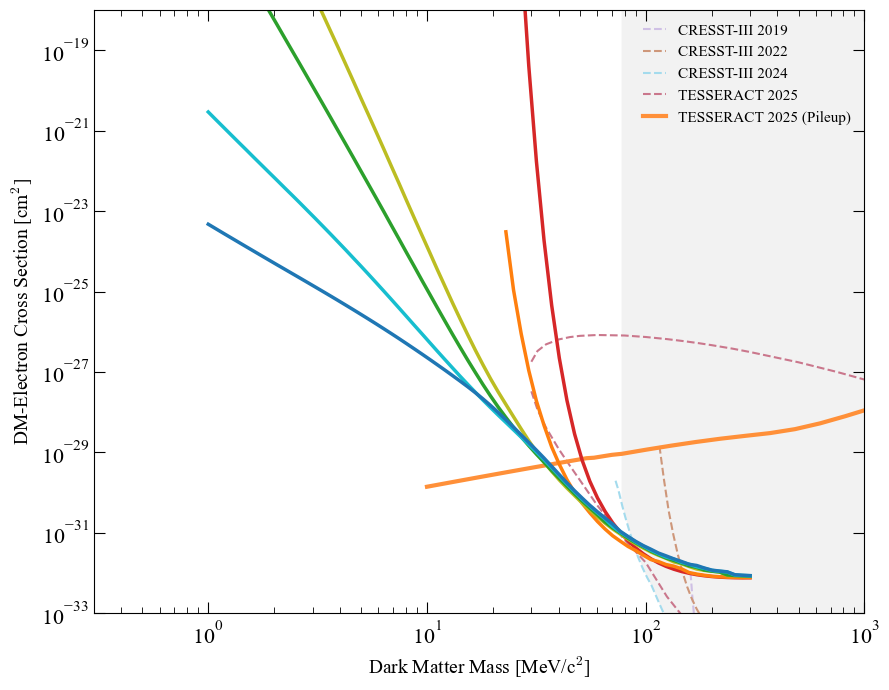

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(9,7))

plotexcludedNR(ax, details=False)
leg_params = {'loc':'upper right',
              'frameon':False,
              'handlelength':1.5,
              'fontsize':11,
              'ncol':1 }
load_and_plot_existing(ax,leg=True,lw=1.5,leg_params=leg_params, ER_model='None')

leg_hands = []

for (baseline_meV, color) in \
    zip([370, 200, 100, 80, 50, 30],
        ['#d62728', '#ff7f0e', '#bcbd22', '#2ca02c', '#17becf', '#1f77b4','#e377c2', '#9467bd', '#8c564b']):
        
    m_limit, x_limit = np.loadtxt(f'projections/sapphire_power_bkgd_1sec_{baseline_meV}meV_NR/limit.txt').transpose()
    #lh, = ax.plot(m_limit*1e3, x_limit, '-', color=color, lw=2.5, label=f'E_threshold = {baseline_meV*5} meV')
    #leg_hands.append(lh)

    m_limit, x_limit = np.loadtxt(f'projections/sapphire_power_bkgd_1sec_{baseline_meV}meV_phonon_massive/limit.txt').transpose()
    ax.plot(m_limit*1e3, x_limit, '-', color=color, lw=2.5)

ax.set_yscale('log')
ax.set_xscale('log')

ax.set_ylim(1e-33, 1e-18)
ax.set_xlim(3e-1, 1e3)
ax.set_xlabel("Dark Matter Mass [MeV/c$^2$]", fontsize=14)
ax.set_ylabel("DM-Electron Cross Section [cm$^2$]", fontsize=14)

#ax.grid(lw=0.3,ls='--',color='grey')
#ax.grid(which="minor", linestyle='dotted')
ax.tick_params(which="both", direction="in", right=True, top=True)

ax.legend(handles=leg_hands, frameon=False, ncol=1, loc='lower left', fontsize=13)

fig.tight_layout()
fig.show()


## Projections: Silicon

/tmp/ipykernel_979286/3201322330.py:14: RuntimeWarning: All-NaN axis encountered
  result = np.nanmin([result, yinterp], axis=0)
/tmp/ipykernel_979286/3201322330.py:87: MatplotlibDeprecationWarning: An artist whose label starts with an underscore was passed to legend(); such artists will no longer be ignored in the future.  To suppress this warning, explicitly filter out such artists, e.g. with `[art for art in artists if not art.get_label().startswith('_')]`.
  leg1 = ax.legend(handles=[l1, l2, l3, l4, l5, l6], **leg_params)


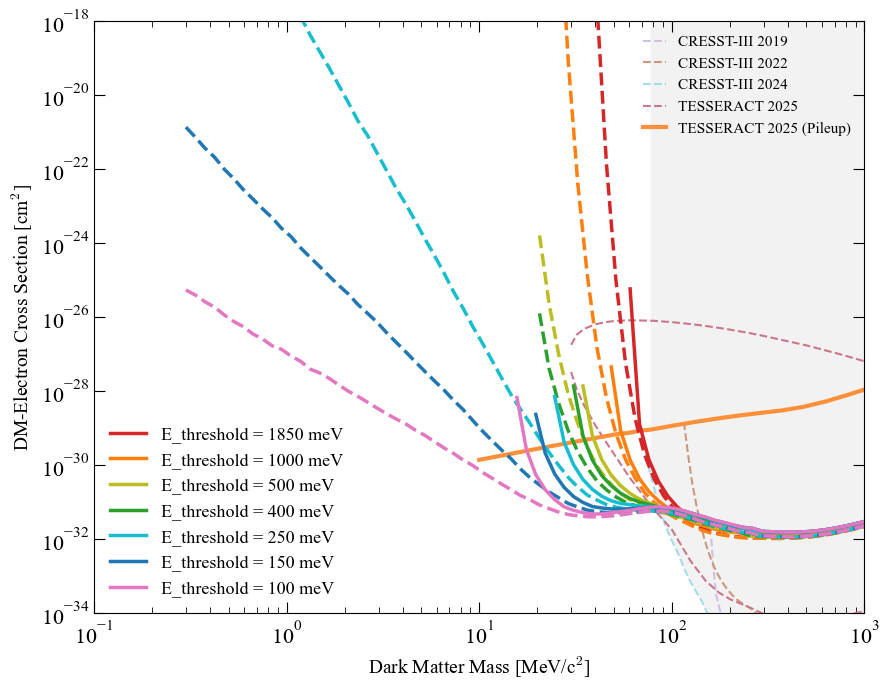

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(9,7))

plotexcludedNR(ax, details=False)
leg_params = {'loc':'upper right',
              'frameon':False,
              'handlelength':1.5,
              'fontsize':11,
              'ncol':1 }
load_and_plot_existing(ax,leg=True,lw=1.5,leg_params=leg_params, ER_model='None')

leg_hands = []



for (baseline_meV, color) in \
    zip([370, 200, 100, 80, 50, 30, 20],
        ['#d62728', '#ff7f0e', '#bcbd22', '#2ca02c', '#17becf', '#1f77b4','#e377c2', '#9467bd', '#8c564b']):
        
    m_limit, x_limit = np.loadtxt(f'projections/silicon_1sec_{baseline_meV}meV_NR/limit.txt').transpose()
    lh, = plt.plot(m_limit*1e3, x_limit, '-', color=color, lw=2.5, label=f'E_threshold = {baseline_meV*5} meV')
    leg_hands.append(lh)

    m_limit, x_limit = np.loadtxt(f'projections/silicon_1sec_{baseline_meV}meV_phonon_massive/limit.txt').transpose()
    ax.plot(m_limit*1e3, x_limit, '--', color=color, lw=2.5)


ax.set_yscale('log')
ax.set_xscale('log')

ax.set_ylim(1e-34, 1e-18)
ax.set_xlim(1e-1, 1e3)
ax.set_xlabel("Dark Matter Mass [MeV/c$^2$]", fontsize=14)
ax.set_ylabel("DM-Electron Cross Section [cm$^2$]", fontsize=14)

#ax.grid(lw=0.3,ls='--',color='grey')
#ax.grid(which="minor", linestyle='dotted')
ax.tick_params(which="both", direction="in", right=True, top=True)

ax.legend(handles=leg_hands, frameon=False, ncol=1, loc='lower left', fontsize=13)

fig.tight_layout()
fig.show()


## Projections: Silicon and Sapphire, compared

/tmp/ipykernel_979286/3201322330.py:14: RuntimeWarning: All-NaN axis encountered
  result = np.nanmin([result, yinterp], axis=0)
/tmp/ipykernel_979286/3201322330.py:87: MatplotlibDeprecationWarning: An artist whose label starts with an underscore was passed to legend(); such artists will no longer be ignored in the future.  To suppress this warning, explicitly filter out such artists, e.g. with `[art for art in artists if not art.get_label().startswith('_')]`.
  leg1 = ax.legend(handles=[l1, l2, l3, l4, l5, l6], **leg_params)
/tmp/ipykernel_979286/1697149380.py:38: MatplotlibDeprecationWarning: An artist whose label starts with an underscore was passed to legend(); such artists will no longer be ignored in the future.  To suppress this warning, explicitly filter out such artists, e.g. with `[art for art in artists if not art.get_label().startswith('_')]`.
  ax.legend(handles=leg_hands, frameon=False, ncol=1, loc='lower left', fontsize=13)


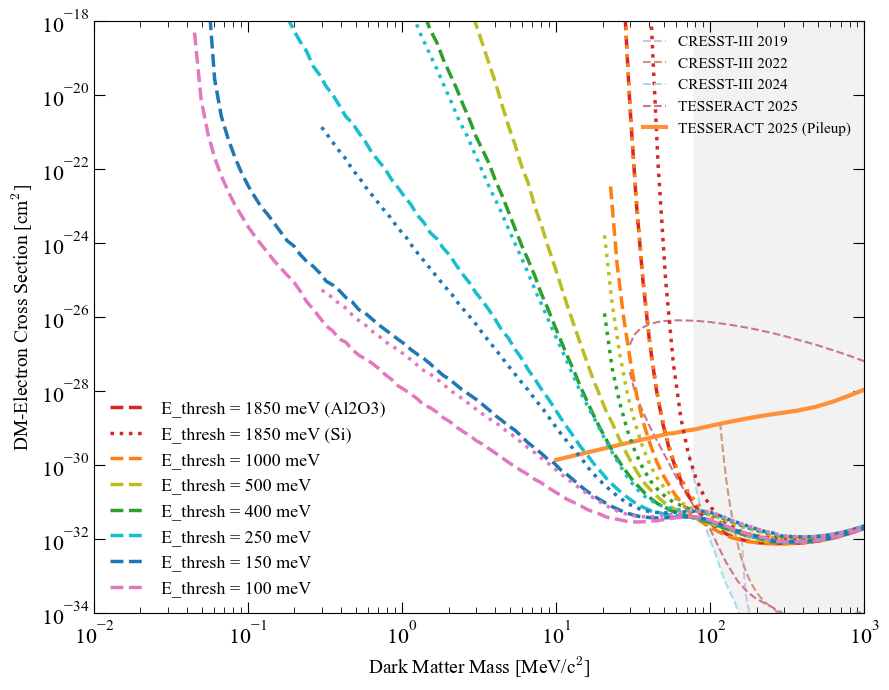

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(9,7))

plotexcludedNR(ax, details=False)
leg_params = {'loc':'upper right',
              'frameon':False,
              'handlelength':1.5,
              'fontsize':11,
              'ncol':1 }
load_and_plot_existing(ax,leg=True,lw=1.5,leg_params=leg_params, ER_model='None')

leg_hands = []

for i, (baseline_meV, color) in \
    enumerate(zip([370, 200, 100, 80, 50, 30, 20],
        ['#d62728', '#ff7f0e', '#bcbd22', '#2ca02c', '#17becf', '#1f77b4','#e377c2', '#9467bd', '#8c564b'])):
        
    m_limit, x_limit = np.loadtxt(f'projections/sapphire_1sec_{baseline_meV}meV_phonon_massive/limit.txt').transpose()
    lh, = plt.plot(m_limit*1e3, x_limit, '--', color=color, lw=2.5, label=f'E_thresh = {5*baseline_meV} meV' + (' (Al2O3)' if i == 0 else ''))
    leg_hands.append(lh)

    m_limit, x_limit = np.loadtxt(f'projections/silicon_1sec_{baseline_meV}meV_phonon_massive/limit.txt').transpose()
    lh, = plt.plot(m_limit*1e3, x_limit, ':', color=color, lw=2.5, label=f'E_thresh = {5*baseline_meV} meV (Si)' if i == 0 else '')
    leg_hands.append(lh)


ax.set_yscale('log')
ax.set_xscale('log')

ax.set_ylim(1e-34, 1e-18)
ax.set_xlim(1e-2, 1e3)
ax.set_xlabel("Dark Matter Mass [MeV/c$^2$]", fontsize=14)
ax.set_ylabel("DM-Electron Cross Section [cm$^2$]", fontsize=14)

#ax.grid(lw=0.3,ls='--',color='grey')
#ax.grid(which="minor", linestyle='dotted')
ax.tick_params(which="both", direction="in", right=True, top=True)

ax.legend(handles=leg_hands, frameon=False, ncol=1, loc='lower left', fontsize=13)

fig.tight_layout()
fig.show()


# Updated Projections from March 2025

/tmp/ipykernel_979286/3201322330.py:14: RuntimeWarning: All-NaN axis encountered
  result = np.nanmin([result, yinterp], axis=0)
/tmp/ipykernel_979286/2801249495.py:38: MatplotlibDeprecationWarning: An artist whose label starts with an underscore was passed to legend(); such artists will no longer be ignored in the future.  To suppress this warning, explicitly filter out such artists, e.g. with `[art for art in artists if not art.get_label().startswith('_')]`.
  ax.legend(handles=leg_hands, frameon=False, ncol=1, loc='lower left', fontsize=13)


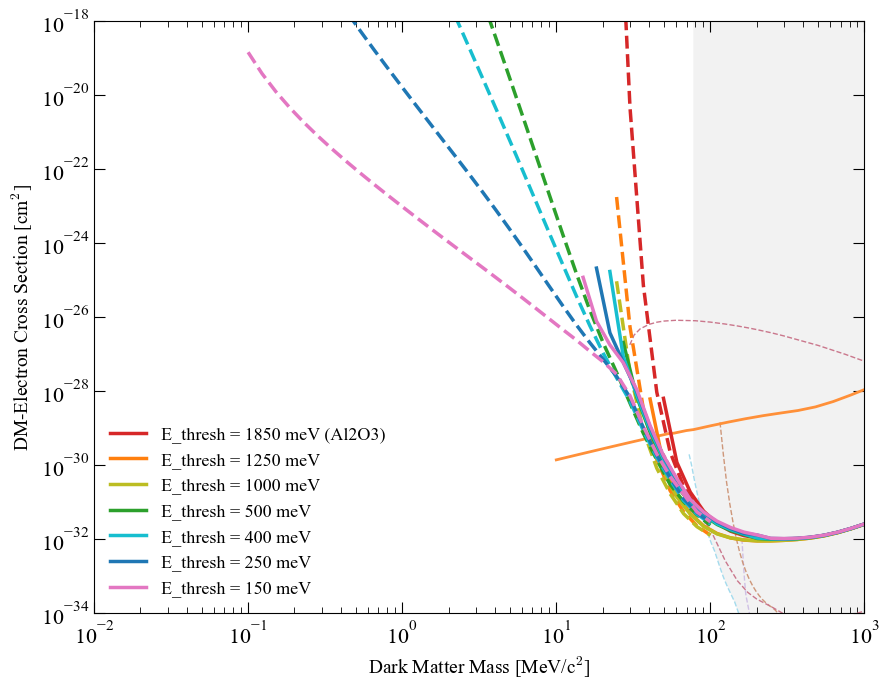

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(9,7))

plotexcludedNR(ax, details=True)
leg_params = {'loc':'upper right',
              'frameon':False,
              'handlelength':1.5,
              'fontsize':11,
              'ncol':1 }
#load_and_plot_existing(ax,leg=True,lw=1.5,leg_params=leg_params, ER_model='None')

leg_hands = []

for i, (baseline_meV, color) in \
    enumerate(zip([370, 250, 200, 100, 80, 50, 30],
        ['#d62728', '#ff7f0e', '#bcbd22', '#2ca02c', '#17becf', '#1f77b4','#e377c2', '#9467bd', '#8c564b'])):
        
       
    m_limit, x_limit = np.loadtxt(f'projections_2025/sapphire_r57_bkgd_1sec_{baseline_meV}meV_NR/limit.txt').transpose()
    lh, = plt.plot(m_limit*1e3, x_limit, '-', color=color, lw=2.5, label=f'E_thresh = {5*baseline_meV} meV' + (' (Al2O3)' if i == 0 else ''))
    leg_hands.append(lh)

    m_limit, x_limit = np.loadtxt(f'projections_2025/sapphire_r57_bkgd_1sec_{baseline_meV}meV_phonon_massive/limit.txt').transpose()
    lh, = plt.plot(m_limit*1e3, x_limit, '--', color=color, lw=2.5)
    leg_hands.append(lh)

ax.set_yscale('log')
ax.set_xscale('log')

ax.set_ylim(1e-34, 1e-18)
ax.set_xlim(1e-2, 1e3)
ax.set_xlabel("Dark Matter Mass [MeV/c$^2$]", fontsize=14)
ax.set_ylabel("DM-Electron Cross Section [cm$^2$]", fontsize=14)

#ax.grid(lw=0.3,ls='--',color='grey')
#ax.grid(which="minor", linestyle='dotted')
ax.tick_params(which="both", direction="in", right=True, top=True)

ax.legend(handles=leg_hands, frameon=False, ncol=1, loc='lower left', fontsize=13)

fig.tight_layout()
fig.show()


/tmp/ipykernel_2727665/2573148309.py:117: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  lowervernefinal.loc[lowervernefinal.index[-3:], "Y"] = new_values


(3.0, 500.0)

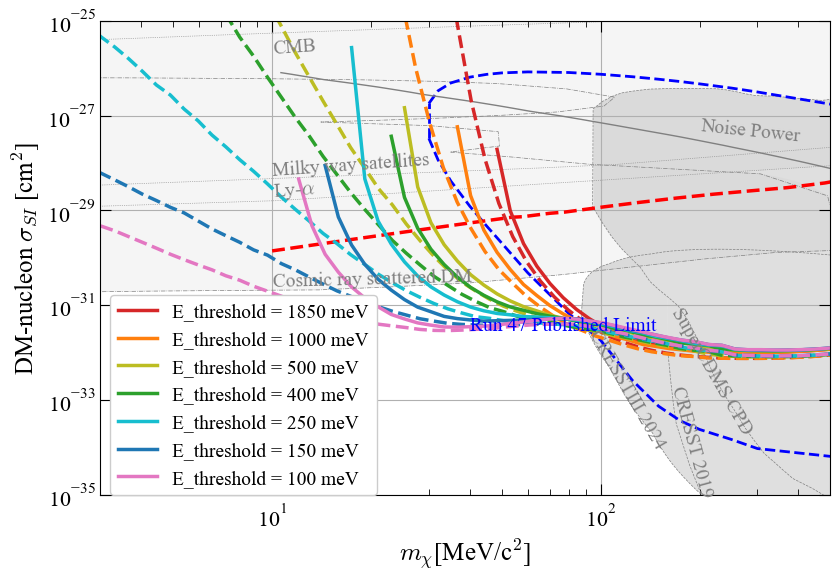

In [8]:
mpl.rcParams.update({'font.size': 14})
def parse_column(value):
    value = value.decode('utf-8').strip() 
    if value == "[inf]":                  
        return np.inf
    return float(value.strip("[]"))       

m_list = np.geomspace(0.01, 10, num=25)
extra_values = np.array([0.07, 0.068, 0.065, 0.063, 0.06, 0.058])
m_list = np.sort(np.concatenate((m_list, extra_values)))

dmlimits = np.genfromtxt(
    "ExistingLimits/run47_NRDM_limit_Final.txt",
    dtype=float,
    converters={1: parse_column}, 
    delimiter=None                 
)

sigma_diff = dmlimits[:,1]

# NR
fig, ax = plt.subplots(figsize=(10, 6.5))
ax.set_xlabel(r"$m_\chi $[MeV/c$^2$]")
ax.set_ylabel(r"DM-nucleon $\sigma_{SI}$ [cm$^2$]")

y_interp = np.logspace(np.log10(np.min(ML.Data_Cosmic_ray[:,1])),
                             np.log10(np.max(ML.Data_Cosmic_ray[:,1])),
                             200)
ax.fill_betweenx(y_interp,
                 np.ones(200)*1e-2,
                 np.interp(y_interp, ML.Data_Cosmic_ray[:,1],ML.Data_Cosmic_ray[:,0]),
                facecolor='whitesmoke')
ax.fill_between(ML.Data_Milky_way_satellites_2021[:,0],
                np.ones(len(ML.Data_Milky_way_satellites_2021[:,0]))*1e-22,
                ML.Data_Milky_way_satellites_2021[:,1],
                facecolor='whitesmoke')      
ax.fill_between(ML.Data_Ly_alpha_2022[:,0],
                np.ones(len(ML.Data_Ly_alpha_2022[:,0]))*1e-22,
                ML.Data_Ly_alpha_2022[:,1],
                facecolor='whitesmoke') 


#ax.loglog(m_sigma_list[:,0]*1e3,limit_rate[3],'r--',alpha=0.5)


ax.loglog(ML.Data_Cosmic_ray[:,0],ML.Data_Cosmic_ray[:,1],
         linewidth=0.5, color='gray', linestyle='-.')
ax.text(1e1,2.5e-31,"Cosmic ray scattered DM",color='gray',rotation=1.5)

ax.loglog(ML.Data_Milky_way_satellites_2021[:,0],ML.Data_Milky_way_satellites_2021[:,1],
         linewidth=0.5, color='gray', linestyle=':')
ax.text(1e1,ML.Data_Milky_way_satellites_2021[11,1],"Milky way satellites",
        color='gray',rotation=4)
ax.loglog(ML.Data_Ly_alpha_2022[:,0],ML.Data_Ly_alpha_2022[:,1],
         linewidth=0.5, color='gray', linestyle=':')
ax.text(1e1,2e-29,r"Ly-$\alpha$",color='gray',rotation=4)
ax.loglog(ML.Data_CMB[:,0],ML.Data_CMB[:,1],
         linewidth=0.5, color='gray', linestyle=':')
ax.text(1e1,0.2e-25,"CMB",color='gray',rotation=4)

ax.fill_between(ML.m_interp_mb*1e3, ML.limit_interp_Upper_max, ML.limit_interp_Lower_min, 
                facecolor='silver',alpha=0.5)
#print(np.minimum(ML.CRESSTIII_2024[:,2], np.interp(ML.CRESSTIII_2024[:,0], ML.m_interp_mb, ML.limit_interp_Upper_max)))
mass_fill_2 = np.sort(np.append(ML.m_interp_mb*1e3, ML.CRESSTIII_2024[:61,0]*1e3))
mass_fill_2 = mass_fill_2[mass_fill_2<200]
ax.fill_between(mass_fill_2,
                np.minimum(np.interp(mass_fill_2, ML.CRESSTIII_2024[:,0]*1e3, ML.CRESSTIII_2024[:,2]),
                           np.interp(mass_fill_2, ML.m_interp_mb*1e3, ML.limit_interp_Lower_min)),
                np.interp(mass_fill_2, ML.CRESSTIII_2024[:,0]*1e3, ML.CRESSTIII_2024[:,1]),
                facecolor='silver',alpha=0.5)
ax.loglog(np.vstack((ML.cpdlimit_down[::-1],ML.cpdlimit_up))[:,0]*1e3, np.vstack((ML.cpdlimit_down[::-1],ML.cpdlimit_up))[:,1],
         linewidth=0.5, color='gray', linestyle='--')

ax.text(1.6e2,2e-34,"SuperCDMS CPD",color='gray',rotation=-60)
#ax.text(1.8e2,2e-35,"SuperCDMS  ",color='gray',rotation=-72)
#ax.text(4e2,3e-36,"CPD",color='gray',rotation=-40)
#ax.loglog(cpdlimit_up[:,0]*1e3, cpdlimit_up[:,1])
#ax.loglog(CRESSTlimit_2022[:,0]*1e3,CRESSTlimit_2022[:,1],
#         linewidth=0.5, color='gray', linestyle='--')
#ax.text(1.25e2,5e-34,"CRESST 2023",color='gray',rotation=-60)

ax.loglog(ML.CRESSTlimit_2019[:,0]*1e3,ML.CRESSTlimit_2019[:,1],
         linewidth=0.5, color='gray', linestyle='--')
ax.text(1.6e2,1e-35,"CRESST 2019",color='gray',rotation=-75)

ax.loglog(ML.CRESSTIII_2024[11:,0]*1e3,ML.CRESSTIII_2024[11:,1],
         linewidth=0.5, color='gray', linestyle='--')
ax.loglog(ML.CRESSTIII_2024[11:,0]*1e3,ML.CRESSTIII_2024[11:,2],
         linewidth=0.5, color='gray', linestyle='--')
ax.text(90,1e-34,"CRESSTIII 2024",color='gray',rotation=-60)

#ax.text(0.9e2,3e-34,"CRESST",color='gray',rotation=-80)

#ax.loglog(Data_Nova_SuperCDMS[:,0],Data_Nova_SuperCDMS[:,1], color='purple')
#ax.loglog(Data_Nova_QP[:,0],Data_Nova_QP[:,1],color='orange')
'''
m_sigma_list = np.transpose([np.logspace(-5,0,26),1e-30*np.ones(26)])
ax.loglog(m_sigma_list[:,0]*1e3,limit_mp[2],'k-',label=r'Massive, correlated noise')
ax.text(0.5,2e-28,"Correlated noise",rotation=-15)
#ax.loglog(m_sigma_list[:,0]*1e3,limit_mp[3],'k--',label=r'Massless, correlated noise')
#ax.loglog(m_sigma_list[:,0]*1e3,limit_Uncorr[2],'k-',label=r'Massive, uncorrelated noise')
#ax.text(0.5,1.5e-26,"Uncorrelated noise",rotation=-12)
#ax.loglog(m_sigma_list[:,0]*1e3,limit_Uncorr[3],'b--',label=r'Massless, uncorrelated noise')
ax.loglog(m_sigma_list[:,0]*1e3,limit_rate[2],'r-',alpha=0.5)
ax.text(0.1,1e-28,r'$R_{total}$=1kHz',color='red',alpha=0.5)
'''
#ax.loglog(m_sigma_list[:,0]*1e3,limit_rate[3],'r--',alpha=0.5)



verne_final = pd.read_csv('ExistingLimits/verne_result_final.cvs')
verne_final.columns = ["X", "Y"]
lowervernefinal = verne_final.iloc[:len(verne_final)//2]
uppervernefinal = verne_final.iloc[len(verne_final)//2:]
new_values = [6.564e-35, 8.029e-35, 1.154e-34]  

lowervernefinal.loc[lowervernefinal.index[-3:], "Y"] = new_values

new_row = pd.DataFrame({"X": [0.03], "Y": [3.30520e-28]})
lowervernefinal = pd.concat([new_row, lowervernefinal], ignore_index=True)


verne_unblind = pd.read_csv('ExistingLimits/verne_result_noblind.cvs')
verne_unblind.columns = ["X", "Y"]
lowerverneunblind = verne_unblind.iloc[:len(verne_unblind)//2]
upperverneunblind = verne_unblind.iloc[len(verne_unblind)//2:]
new_values = [5.02397519e-35,6.09179215e-35, 8.57781172e-35]  

verne_unblind.iloc[-3:, 1] = new_values

ax.loglog(lowervernefinal["X"]*1e3, lowervernefinal["Y"],'b--')
#ax.loglog(verne_unblind["X"]*1e3, verne_unblind["Y"],'k--',label='Unrestricted')

ax.loglog(uppervernefinal["X"]*1e3, uppervernefinal["Y"],'b--')


#m_list = lowervernefinal["X"]

#m_list = np.array(m_list)
#lowervernefinal = np.array(lowervernefinal["Y"])

# Ensure sorting is done correctly
#sorted_indices = np.argsort(m_list)
#m_list = m_list[sorted_indices]
#lowervernefinal = lowervernefinal[sorted_indices]


#Noise Limit
NoiseLimit= np.array(np.loadtxt("ExistingLimits/NoiseLimitR47.txt"))

#ax.plot(NoiseLimit[:,0],NoiseLimit[:,1],
#         linewidth=2, color='Black', linestyle='-',label='Noise Limit')


m_list_for_plot = m_list[m_list>=0.045]
sigma_diff_for_plot = sigma_diff[m_list>=0.045] #sigma_diff[m_list>=0.041]
m_list_for_plot=np.insert(m_list_for_plot, 0, 0.045)
sigma_diff_for_plot = np.insert(sigma_diff_for_plot, 0, interpolate.interp1d(m_list,sigma_diff)(0.045))
m_list_for_plot=np.insert(m_list_for_plot, 0, 0.045)

# R_5kHz_60MeV = interpolate.interp1d(m_list, 1e-41*5e3/(0.23e-3*np.array(R_m)/3600/24))(0.045)
# sigma_diff_for_plot = np.insert(sigma_diff_for_plot, 0, R_5kHz_60MeV)
#ax.loglog(m_list_for_plot*1e3,sigma_diff_for_plot,'b',label='TESSERACT\n'+r'1cm$^2$ Device')
#ax.loglog(m_list[:]*1e3,sigma_diff[:],'k--',alpha=0.7,label='No Overburden Lower')



#ax.loglog(lowerverneunblind["X"]*1e3, lowerverneunblind["Y"],'y--')

#ax.loglog(verne_unblind["X"]*1e3, verne_unblind["Y"],'y--')
#ax.loglog(TriggerLimits[:,0]*1e3,TriggerLimits[:,1],'b--',label=r'No boost')
#ax.text(30,10e-34,"",color='b',rotation=-60)
#ax.loglog(np.array(m_list_Upper_8hour_3m[8:])*1e3,limit_Upper_8hour_3m[8:],'b')
m_list_dash = m_list[m_list<=0.045]
sigma_diff_dash= sigma_diff[m_list<=0.045]
#ax.loglog(np.append(np.array(m_list_Upper_8hour_3m[::-1])*1e3, m_list_dash[5:]*1e3),
#          np.append(limit_Upper_8hour_3m[::-1], sigma_diff_dash[5:]),
#          'g--',label='Overburden Constraint',alpha=0.7)

#ax.loglog(np.array(m_list_Upper_8hour_3m[0:8])*1e3,limit_Upper_8hour_3m[0:8],'b--')
#upper limit - 5kHz

# R_5kHz_plot = np.insert(1e-41*5.5e3/(0.23e-3*np.array(R_m)[m_list>=0.045]/3600/24), 0,  R_5kHz_60MeV)
# m_5kHz_plot = np.insert(m_list[m_list>=0.045],0,0.045)
# #ax.loglog(m_5kHz_plot*1e3, R_5kHz_plot,'r--')
# ax.loglog(m_list*1e3, 1e-41*5.5e3/(0.23e-3*np.array(R_m)/3600/24),color='r',linestyle=':',alpha=0.7)
# print(1e-41*5.5e3/(0.23e-3*np.array(R_m)/3600/24))
#ax.text(45,1e-29,r'$R_{Total}$ = 5.5 kHz',color='r',rotation=7)
#ax.text(45,1e-29,'Pileup Constraint',color='r',rotation=7,size = 8)
#ax.text(90,2e-27,'Overburden Constraint',color='g',rotation=-7)
ax.text(4e1, 3e-32, 'Run 47 Published Limit',color='b')
fillmass = lowervernefinal["X"] 
mask = fillmass > 0.04
fillmass = fillmass[mask] 
fillsig = lowervernefinal["Y"][mask]

corrlimx = [0.06*1e3,0.06*1e3]
corrlimy = [5.05e-31, 7e-30]
#ax.loglog(corrlimx, corrlimy, color = 'purple',linestyle = '-',label = "Mass Cutoff")

# ax.fill_between(fillmass*1e3,
#                 fillsig,
#                  np.interp(fillmass, m_5kHz_plot,R_5kHz_plot),
#                 facecolor='blue',alpha=0.2,label='TESSERACT-Si\n' 'Exclusion')

x_values = [0.03*1e3, 0.03*1e3]  # Same x for both points (vertical line)
y_values = [3.30520e-28, 1.79855e-27]

# Plot the line
ax.loglog(x_values, y_values, 'b--')



# Add Kurinsky curve
das_kurinsky = np.genfromtxt(
    "ExistingLimits/Das_Kurinsky_2024.txt",
    dtype=float,
    converters={1: parse_column}, 
    delimiter=None                 
)

ax.loglog(das_kurinsky[:,0]*1e3, das_kurinsky[:,1], color='gray', linewidth=1.)
ax.text(2e2, 0.3e-27, "Noise Power",color='gray',rotation=-6)



def parse_column(value):
    value = value.decode('utf-8').strip() 
    if value == "[inf]":                  
        return np.inf
    return float(value.strip("[]"))  
oldlims = np.genfromtxt(
    "ExistingLimits/run47_NRDM_limit_noboost_nodrde.txt",
    dtype=float,
    converters={1: parse_column}, 
    delimiter=None                 
)

r57lims = np.genfromtxt(
    "ExistingLimits/run57_NRDM_limit_noboost_nodrde.txt",
    dtype=float,
    converters={1: parse_column}, 
    delimiter=None                 
)

r57lims_sapphire = np.genfromtxt(
    "ExistingLimits/run57_sapphire_NRDM_limit_noboost_nodrde.txt",
    dtype=float,
    converters={1: parse_column}, 
    delimiter=None                 
)

r57lims_sapphire_phonon = np.genfromtxt(
    "ExistingLimits/run57_sapphire_phonon_limit_noboost_nodrde.txt",
    dtype=float,
    converters={1: parse_column}, 
    delimiter=None                 
)

# ax.loglog(oldlims[:,0]*1e3, oldlims[:,1], color='g',label=r"Run 47 Limits - No boost or dRdE",lw=2.5,alpha=0.75)
# ax.loglog(r57lims[:,0]*1e3, r57lims[:,1], color='m',label=r"Run 57 Limits - No boost or dRdE",lw=2.5,alpha=0.75)
# ax.loglog(r57lims_sapphire[:,0]*1e3, r57lims_sapphire[:,1], color='brown',label=r"Run 57 Sapphire",lw=2.5,alpha=0.75)
# ax.loglog(r57lims_sapphire_phonon[:,0]*1e3, r57lims_sapphire_phonon[:,1], '--', color='brown',label=r"Run 57 Sapphire Multiphonon",lw=2.5,alpha=0.75)

r47_pileup = np.genfromtxt(
    "ExistingLimits/TESSERACT_2025_Pileup.txt",
    dtype=float,
    converters={1: parse_column}, 
    delimiter=None                 
)
ax.loglog(r47_pileup[:,0]*1e3, r47_pileup[:,1], '--', color='r', lw=2.5)
ax.text(4, 8e-33,'Run 47 Pileup Constraint', color='r')


for i, (baseline_meV, color) in \
    enumerate(zip([370, 200, 100, 80, 50, 30, 20],
        ['#d62728', '#ff7f0e', '#bcbd22', '#2ca02c', '#17becf', '#1f77b4','#e377c2', '#9467bd', '#8c564b'])):
       
    # m_limit, x_limit = np.loadtxt(f'projections_2025/sapphire_r57_bkgd_1sec_{baseline_meV}meV_NR/limit.txt').transpose()
    # ax.plot(m_limit*1e3, x_limit, '-', color=color, lw=2.5, label=f'E_thresh = {5*baseline_meV} meV')# + (' (Al2O3)' if i == 0 else ''))

    # m_limit, x_limit = np.loadtxt(f'projections_2025/sapphire_r57_bkgd_1sec_{baseline_meV}meV_phonon_massive/limit.txt').transpose()
    # ax.plot(m_limit*1e3, x_limit, '--', color=color, lw=2.5)

    # m_limit, x_limit = np.loadtxt(f'projections_2025/sapphire_r57_bkgd_10sec_{baseline_meV}meV_NR/limit.txt').transpose()
    # ax.plot(m_limit*1e3, x_limit, '-', color=color, lw=2.5)

    m_limit, x_limit = np.loadtxt(f'projections/sapphire_1sec_{baseline_meV}meV_NR/limit.txt').transpose()
    ax.plot(m_limit*1e3, x_limit, '-', color=color, lw=2.5, label=f'E_threshold = {baseline_meV*5} meV')

    m_limit, x_limit = np.loadtxt(f'projections/sapphire_1sec_{baseline_meV}meV_phonon_massive/limit.txt').transpose()
    ax.plot(m_limit*1e3, x_limit, '--', color=color, lw=2.5)

#ax.loglog([0.044*1e3,0.4*1e3],[4e-32,4e-32],'k-')
ax.grid()
ax.legend(loc='lower left', frameon=True, bbox_to_anchor=(0, -0.02), framealpha=1)
ax.set_ylim(1e-35,1e-25)
ax.set_xlim(3e0,5e2)
#fig.savefig('/home/michael/DarkLim/examples/Run47Limit_NR_paper.pdf',bbox_inches="tight")

#print(np.transpose([m_list_for_plot*1e3,sigma_diff_for_plot]))